In [159]:
# Import libraries
import pandas as pd
import numpy as np

In [160]:
# Load the Excel workbook
file_path = "../data/NorthBridgeDataset.xlsx"

excel_file = pd.ExcelFile(file_path)

# View all sheet names
excel_file.sheet_names

['README',
 'PriorityLevels',
 'TicketCategories',
 'SLADefinitions',
 'Agents',
 'Clients',
 'Tickets',
 'TicketAuditLog',
 'EscalationLog']

In [161]:
# Load the main tables
tickets = pd.read_excel(file_path, sheet_name="Tickets")
clients = pd.read_excel(file_path, sheet_name="Clients")
agents = pd.read_excel(file_path, sheet_name="Agents")

In [162]:
# Check the size of each table
print("Tickets:", tickets.shape)
print("Clients:", clients.shape)
print("Agents:", agents.shape)

Tickets: (3500, 16)
Clients: (80, 10)
Agents: (120, 8)


In [163]:
# Preview the Tickets table
tickets.head()

,TicketID,TicketReference,ClientID,PatientRef,CategoryID,PriorityID,Status,AssignedAgentID,CreatedAt,FirstResponseAt,ResolvedAt,SLADueAt,SLABreached,Channel,Description,ResolutionNotes
0,1,NB-2024-00001,70,PT-81496,5,3,Closed,111,2024-07-24 23:41,2024-07-25 02:27,2024-07-27 10:35,2024-07-27 23:41,0,Phone,Request for discharge summary for patient PT-8...,Insurance medical report completed and submitt...
1,2,NB-2024-00002,51,PT-99051,2,1,Closed,32,2024-11-06 23:45,2024-11-07 01:09,2024-11-07 04:44,2024-11-07 07:45,0,Portal,Query regarding invoice 28714 dated 09 Oct 202...,Charge dispute investigated. Original amount v...
2,3,NB-2024-00003,53,PT-24869,3,3,Closed,57,2024-08-01 05:39,2024-08-01 09:58,2024-08-02 14:35,2024-08-04 05:39,0,Portal,Pre-authorisation request for outpatient consu...,Pre-auth declined by insurer. Patient advised ...
3,4,NB-2024-00004,11,PT-55537,1,2,Closed,22,2024-12-03 13:22,2024-12-03 14:47,2024-12-04 07:32,2024-12-04 01:22,1,Form,Patient PT-55537 requesting addition of appoin...,Cancellation processed. New appointment booked...
4,5,NB-2023-00005,70,PT-50539,3,2,Resolved,52,2023-02-11 03:56,2023-02-11 06:27,2023-02-11 12:26,2023-02-12 03:56,0,Phone,Pre-authorisation request for surgical procedu...,Pre-authorisation confirmed with insurer. Refe...


In [164]:
# Check column names, data types, and missing values
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TicketID         3500 non-null   int64
 1   TicketReference  3500 non-null   str  
 2   ClientID         3500 non-null   int64
 3   PatientRef       3500 non-null   str  
 4   CategoryID       3500 non-null   int64
 5   PriorityID       3500 non-null   int64
 6   Status           3500 non-null   str  
 7   AssignedAgentID  3500 non-null   int64
 8   CreatedAt        3500 non-null   str  
 9   FirstResponseAt  3454 non-null   str  
 10  ResolvedAt       3301 non-null   str  
 11  SLADueAt         3500 non-null   str  
 12  SLABreached      3500 non-null   int64
 13  Channel          3500 non-null   str  
 14  Description      3500 non-null   str  
 15  ResolutionNotes  3301 non-null   str  
dtypes: int64(6), str(10)
memory usage: 437.6 KB


In [165]:
# Check for duplicate rows
print("Duplicate rows:", tickets.duplicated().sum())

# Check SLA breach distribution
print(tickets["SLABreached"].value_counts())

# Check SLA breach percentage
print(tickets["SLABreached"].value_counts(normalize=True) * 100)

Duplicate rows: 0
SLABreached
0    2746
1     754
Name: count, dtype: int64
SLABreached
0    78.457143
1    21.542857
Name: proportion, dtype: float64


So the target is imbalanced, but not horribly imbalanced. About 1 out of every 5 tickets breached its SLA.

In [166]:
# Check missing values in the Tickets table
tickets.isnull().sum()

TicketID             0
TicketReference      0
ClientID             0
PatientRef           0
CategoryID           0
PriorityID           0
Status               0
AssignedAgentID      0
CreatedAt            0
FirstResponseAt     46
ResolvedAt         199
SLADueAt             0
SLABreached          0
Channel              0
Description          0
ResolutionNotes    199
dtype: int64

In [167]:
# Check ticket status distribution
tickets["Status"].value_counts()

Status
Closed            1984
Resolved          1317
Escalated           57
In Progress         52
Open                46
Pending Client      44
Name: count, dtype: int64

In [168]:
# Check the status of tickets with no resolution date
tickets.loc[tickets["ResolvedAt"].isnull(), "Status"].value_counts()

Status
Escalated         57
In Progress       52
Open              46
Pending Client    44
Name: count, dtype: int64

In [169]:
# Check the status of tickets with no first response
tickets.loc[tickets["FirstResponseAt"].isnull(), "Status"].value_counts()

Status
Open    46
Name: count, dtype: int64

Missing values were found only in three columns of the Tickets table:

- `FirstResponseAt` – 46 missing values
- `ResolvedAt` – 199 missing values
- `ResolutionNotes` – 199 missing values

Further investigation showed that all 46 tickets without a `FirstResponseAt` value have a status of `Open`, meaning they have not yet received a first response.

The 199 tickets without a `ResolvedAt` value are still active, with statuses including `Escalated`, `In Progress`, `Open`, and `Pending Client`. These same unresolved tickets also have missing `ResolutionNotes`.

Therefore, the missing values are considered valid operational missingness rather than data-quality errors. No values were filled or removed because doing so would introduce inaccurate information into the dataset.

In [170]:
# Inspect Clients table
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ClientID           80 non-null     int64
 1   ClientName         80 non-null     str  
 2   ClientType         80 non-null     str  
 3   ContractTier       80 non-null     str  
 4   AccountManagerID   80 non-null     int64
 5   Region             80 non-null     str  
 6   ContractStartDate  80 non-null     str  
 7   ContractEndDate    80 non-null     str  
 8   SLACreditClause    80 non-null     int64
 9   IsActive           80 non-null     int64
dtypes: int64(4), str(6)
memory usage: 6.4 KB


In [171]:
# Preview Clients table
clients.head()

,ClientID,ClientName,ClientType,ContractTier,AccountManagerID,Region,ContractStartDate,ContractEndDate,SLACreditClause,IsActive
0,1,Ashworth Medical Centre,Private Hospital,Premium,41,South East,2010-05-01,2013-10-19,0,1
1,2,Unity Health Clinic,Dental Group,Enterprise,92,Midlands,2016-03-01,2018-04-16,0,1
2,3,Junction Health Clinic,Private Hospital,Premium,76,Midlands,2014-08-01,2017-03-27,1,1
3,4,Arcadia Health Group,Mental Health Clinic,Enterprise,59,Yorkshire,2023-11-01,2028-08-12,1,1
4,5,Parkside Specialist Clinic,Private Hospital,Standard,102,Scotland,2014-09-01,2016-05-11,0,1


In [172]:
# Inspect Agents table
agents.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   AgentID        120 non-null    int64
 1   FullName       120 non-null    str  
 2   TeamID         120 non-null    int64
 3   Role           120 non-null    str  
 4   Specialisms    120 non-null    str  
 5   Hub            120 non-null    str  
 6   DailyCapacity  120 non-null    int64
 7   IsActive       120 non-null    int64
dtypes: int64(4), str(4)
memory usage: 7.6 KB


In [173]:
# Preview Agents table
agents.head()

,AgentID,FullName,TeamID,Role,Specialisms,Hub,DailyCapacity,IsActive
0,1,Parveen Szymański,1,Senior Agent,"Document Request,Insurance Query,Appointment C...",Manchester,16,1
1,2,Kirsty Morrison,1,Team Lead,"Document Request,Insurance Query,Complaint",Manchester,11,1
2,3,Alexander Johnson,1,Senior Agent,"Appointment Change,Billing Issue",Manchester,19,1
3,4,Eleanor Patel,1,Agent,"Insurance Query,Complaint",Manchester,19,1
4,5,Aisha Szymański,1,Agent,"Insurance Query,Appointment Change,Document Re...",Manchester,21,1


Do all the ClientID and AssignedAgentID values in Tickets actually exist in the Clients and Agents tables?

In [174]:
# Check for duplicate IDs in Clients and Agents
print("Duplicate Client IDs:", clients["ClientID"].duplicated().sum())
print("Duplicate Agent IDs:", agents["AgentID"].duplicated().sum())

Duplicate Client IDs: 0
Duplicate Agent IDs: 0


In [175]:
# Check for Ticket ClientIDs that do not exist in Clients
missing_clients = set(tickets["ClientID"]) - set(clients["ClientID"])

# Check for Ticket AssignedAgentIDs that do not exist in Agents
missing_agents = set(tickets["AssignedAgentID"]) - set(agents["AgentID"])

print("Unmatched Client IDs:", missing_clients)
print("Unmatched Agent IDs:", missing_agents)

Unmatched Client IDs: set()
Unmatched Agent IDs: set()


What kinds of tickets, clients, and agents actually exist in this dataset?

In [176]:
# Check unique values in key ticket columns
print("Status values:")
print(tickets["Status"].value_counts())

print("\nChannel values:")
print(tickets["Channel"].value_counts())

print("\nPriority IDs:")
print(tickets["PriorityID"].value_counts().sort_index())

print("\nCategory IDs:")
print(tickets["CategoryID"].value_counts().sort_index())

Status values:
Status
Closed            1984
Resolved          1317
Escalated           57
In Progress         52
Open                46
Pending Client      44
Name: count, dtype: int64

Channel values:
Channel
Email     1221
Portal     977
Phone      905
Form       397
Name: count, dtype: int64

Priority IDs:
PriorityID
1     258
2     833
3    1981
4     428
Name: count, dtype: int64

Category IDs:
CategoryID
1    1200
2     873
3     706
4     306
5     415
Name: count, dtype: int64


In [177]:
# Check key client categories
print("Contract Tier:")
print(clients["ContractTier"].value_counts())

print("\nRegion:")
print(clients["Region"].value_counts())

Contract Tier:
ContractTier
Standard      37
Premium       29
Enterprise    14
Name: count, dtype: int64

Region:
Region
Midlands      21
Scotland      13
South East    12
North East    12
Yorkshire     11
North West    11
Name: count, dtype: int64


In [178]:
# Check key agent categories
print("Hub:")
print(agents["Hub"].value_counts())

print("\nRole:")
print(agents["Role"].value_counts())

print("\nDaily Capacity Summary:")
print(agents["DailyCapacity"].describe())

Hub:
Hub
Manchester    42
Leeds         28
Birmingham    28
Edinburgh     22
Name: count, dtype: int64

Role:
Role
Agent                 92
Senior Agent          18
Team Lead              9
Operations Manager     1
Name: count, dtype: int64

Daily Capacity Summary:
count    120.000000
mean      20.925000
std        4.692498
min        6.000000
25%       19.000000
50%       21.000000
75%       24.250000
max       28.000000
Name: DailyCapacity, dtype: float64


Inspect the lookup tables

In [21]:
# Load supporting lookup tables
priority_levels = pd.read_excel(file_path, sheet_name="PriorityLevels")
ticket_categories = pd.read_excel(file_path, sheet_name="TicketCategories")
sla_definitions = pd.read_excel(file_path, sheet_name="SLADefinitions")

In [22]:
# View priority definitions
priority_levels

,PriorityID,PriorityLabel,Description
0,1,P1 Critical,"Immediate risk to patient safety, legal/regula..."
1,2,P2 High,"Significant financial impact, complaint from c..."
2,3,P3 Standard,Routine service request with defined SLA. Stan...
3,4,P4 Low,"Informational queries, minor updates, or reque..."


In [23]:
# View ticket category definitions
ticket_categories

,CategoryID,CategoryName,DefaultPriorityID,RequiresSpecialist,Description
0,1,Appointment Change,3,0,"Request to reschedule, cancel, or add a patien..."
1,2,Billing Issue,2,1,"Disputes, queries, or corrections relating to ..."
2,3,Insurance Query,2,1,"Queries about pre-authorisation, claim status,..."
3,4,Complaint,2,0,Formal or informal patient or client complaint...
4,5,Document Request,3,0,"Requests for medical records, letters, referra..."


In [24]:
# View SLA definitions
sla_definitions

,SLAID,ContractTier,PriorityID,FirstResponseHours,ResolutionHours,EscalationTriggerHours,EffectiveFrom
0,1,Standard,1,2.0,8,6.0,2023-01-01
1,2,Standard,2,4.0,24,20.0,2023-01-01
2,3,Standard,3,8.0,72,60.0,2023-01-01
3,4,Standard,4,24.0,120,100.0,2023-01-01
4,5,Premium,1,1.0,4,3.0,2023-01-01
5,6,Premium,2,2.0,12,10.0,2023-01-01
6,7,Premium,3,4.0,48,40.0,2023-01-01
7,8,Premium,4,12.0,96,80.0,2023-01-01
8,9,Enterprise,1,0.5,2,1.5,2023-01-01
9,10,Enterprise,2,1.0,8,6.0,2023-01-01


Create the modelling table

In [25]:
# Add selected client information to each ticket
model_data = tickets.merge(
    clients[
        [
            "ClientID",
            "ContractTier",
            "SLACreditClause"
        ]
    ],
    on="ClientID",
    how="left"
)

# Add selected agent information to each ticket
model_data = model_data.merge(
    agents[
        [
            "AgentID",
            "TeamID",
            "Hub",
            "DailyCapacity"
        ]
    ],
    left_on="AssignedAgentID",
    right_on="AgentID",
    how="left"
)

# Check the new table size
model_data.shape

(3500, 22)

In [26]:
# Preview the combined modelling dataset
model_data.head()

,TicketID,TicketReference,ClientID,PatientRef,CategoryID,PriorityID,Status,AssignedAgentID,CreatedAt,FirstResponseAt,...,SLABreached,Channel,Description,ResolutionNotes,ContractTier,SLACreditClause,AgentID,TeamID,Hub,DailyCapacity
0,1,NB-2024-00001,70,PT-81496,5,3,Closed,111,2024-07-24 23:41,2024-07-25 02:27,...,0,Phone,Request for discharge summary for patient PT-8...,Insurance medical report completed and submitt...,Standard,0,111,8,Edinburgh,16
1,2,NB-2024-00002,51,PT-99051,2,1,Closed,32,2024-11-06 23:45,2024-11-07 01:09,...,0,Portal,Query regarding invoice 28714 dated 09 Oct 202...,Charge dispute investigated. Original amount v...,Standard,0,32,1,Manchester,8
2,3,NB-2024-00003,53,PT-24869,3,3,Closed,57,2024-08-01 05:39,2024-08-01 09:58,...,0,Portal,Pre-authorisation request for outpatient consu...,Pre-auth declined by insurer. Patient advised ...,Standard,0,57,4,Leeds,21
3,4,NB-2024-00004,11,PT-55537,1,2,Closed,22,2024-12-03 13:22,2024-12-03 14:47,...,1,Form,Patient PT-55537 requesting addition of appoin...,Cancellation processed. New appointment booked...,Premium,1,22,1,Manchester,27
4,5,NB-2023-00005,70,PT-50539,3,2,Resolved,52,2023-02-11 03:56,2023-02-11 06:27,...,0,Phone,Pre-authorisation request for surgical procedu...,Pre-authorisation confirmed with insurer. Refe...,Standard,0,52,4,Leeds,26


In [27]:
# Check for missing values created by the joins
model_data[
    [
        "ContractTier",
        "SLACreditClause",
        "TeamID",
        "Hub",
        "DailyCapacity"
    ]
].isnull().sum()

ContractTier       0
SLACreditClause    0
TeamID             0
Hub                0
DailyCapacity      0
dtype: int64


The Tickets, Clients, and Agents tables were successfully merged to create the modelling dataset.

- The combined dataset contains **3,500 rows and 22 columns**.
- The number of rows remained unchanged after the merge, confirming that no ticket records were lost.
- Client information such as `ContractTier` and `SLACreditClause` was successfully added using `ClientID`.
- Agent information such as `TeamID`, `Hub`, and `DailyCapacity` was added using `AssignedAgentID`.
- No missing values were introduced in the newly joined client and agent features.

This confirms that the relationships between the Tickets, Clients, and Agents tables are valid and the combined dataset is ready for further feature preparation and exploratory analysis.

In [28]:
# Convert ticket creation time to datetime
model_data["CreatedAt"] = pd.to_datetime(model_data["CreatedAt"])

# Check the result
model_data["CreatedAt"].dtype

dtype('<M8[us]')

In [29]:
# Create time-based features from ticket creation date
model_data["CreatedHour"] = model_data["CreatedAt"].dt.hour
model_data["CreatedDayOfWeek"] = model_data["CreatedAt"].dt.day_name()
model_data["CreatedMonth"] = model_data["CreatedAt"].dt.month

In [30]:
model_data[
    ["CreatedAt", "CreatedHour", "CreatedDayOfWeek", "CreatedMonth"]
].head()

,CreatedAt,CreatedHour,CreatedDayOfWeek,CreatedMonth
0,2024-07-24 23:41:00,23,Wednesday,7
1,2024-11-06 23:45:00,23,Wednesday,11
2,2024-08-01 05:39:00,5,Thursday,8
3,2024-12-03 13:22:00,13,Tuesday,12
4,2023-02-11 03:56:00,3,Saturday,2


The `CreatedAt` column was successfully converted from text to datetime format.

Three new time-based features were created from the ticket creation timestamp:

- `CreatedHour` – shows the hour of the day the ticket was created
- `CreatedDayOfWeek` – shows the day of the week the ticket was created
- `CreatedMonth` – shows the month the ticket was created

The preview confirms that these features were extracted correctly. These variables can be used during exploratory analysis to check whether SLA breaches are more common at certain times, on specific days, or during particular months.

In [31]:
# Check whether TicketID contains duplicate values
print("Duplicate Ticket IDs:", tickets["TicketID"].duplicated().sum())

# Check whether TicketReference contains duplicate values
print("Duplicate Ticket References:", tickets["TicketReference"].duplicated().sum())

Duplicate Ticket IDs: 0
Duplicate Ticket References: 0


In [32]:
# Check whether all PriorityIDs in Tickets exist in the PriorityLevels table
invalid_priorities = set(tickets["PriorityID"]) - set(priority_levels["PriorityID"])

# Check whether all CategoryIDs in Tickets exist in the TicketCategories table
invalid_categories = set(tickets["CategoryID"]) - set(ticket_categories["CategoryID"])

print("Invalid Priority IDs:", invalid_priorities)
print("Invalid Category IDs:", invalid_categories)

Invalid Priority IDs: set()
Invalid Category IDs: set()


The identifier and lookup checks were successfully completed.

- `TicketID` contains no duplicate values.
- `TicketReference` contains no duplicate values.
- All `PriorityID` values in the Tickets table match valid records in the PriorityLevels table.
- All `CategoryID` values in the Tickets table match valid records in the TicketCategories table.

This confirms that ticket identifiers are unique and that the priority and category references are consistent across the dataset.

In [33]:
# Convert relevant ticket timestamp columns to datetime format
tickets["CreatedAt"] = pd.to_datetime(tickets["CreatedAt"])
tickets["FirstResponseAt"] = pd.to_datetime(tickets["FirstResponseAt"])
tickets["ResolvedAt"] = pd.to_datetime(tickets["ResolvedAt"])
tickets["SLADueAt"] = pd.to_datetime(tickets["SLADueAt"])

# Check for tickets where the first response occurred before the ticket was created
response_before_creation = (
    tickets["FirstResponseAt"].notna()
    & (tickets["FirstResponseAt"] < tickets["CreatedAt"])
)

# Check for tickets where resolution occurred before the ticket was created
resolution_before_creation = (
    tickets["ResolvedAt"].notna()
    & (tickets["ResolvedAt"] < tickets["CreatedAt"])
)

# Check for tickets where SLA due time occurred before ticket creation
sla_before_creation = (
    tickets["SLADueAt"] < tickets["CreatedAt"]
)

print("First response before creation:", response_before_creation.sum())
print("Resolution before creation:", resolution_before_creation.sum())
print("SLA due before creation:", sla_before_creation.sum())

First response before creation: 0
Resolution before creation: 0
SLA due before creation: 0


The timestamp consistency checks were successfully completed.

- No ticket had a `FirstResponseAt` value earlier than its `CreatedAt` time.
- No ticket had a `ResolvedAt` value earlier than its `CreatedAt` time.
- No ticket had an `SLADueAt` value earlier than its `CreatedAt` time.

This confirms that the ticket timestamps are logically consistent and no invalid date sequences were identified.

## Data Validation Summary

The NorthBridge dataset was reviewed for missing values, duplicates, identifier consistency, table relationships, lookup validity, and timestamp accuracy.

The Tickets table contains 3,500 records with no duplicate rows, while `TicketID` and `TicketReference` are unique. The Clients and Agents tables contain no missing values or duplicate primary IDs.

All client, agent, priority, and category references used in the Tickets table successfully matched their corresponding lookup tables, confirming that the relationships between the datasets are valid.

Missing values were found only in `FirstResponseAt`, `ResolvedAt`, and `ResolutionNotes`. Further investigation showed that these values belong to open or unresolved tickets, so they were retained as valid operational missingness rather than treated as data-quality errors.

The `SLABreached` target is complete, with approximately 21.54% of tickets breaching SLA and 78.46% meeting SLA.

Timestamp checks also confirmed that no first response, resolution, or SLA deadline occurred before the corresponding ticket creation time.

Overall, the core dataset is clean, consistent, and suitable for feature engineering and exploratory data analysis.

### Exploratory Data Analysis (EDA)

In [34]:
# Add readable priority labels to the modelling dataset
model_data = model_data.merge(
    priority_levels[
        [
            "PriorityID",
            "PriorityLabel"
        ]
    ],
    on="PriorityID",
    how="left"
)

# Add readable ticket category names to the modelling dataset
model_data = model_data.merge(
    ticket_categories[
        [
            "CategoryID",
            "CategoryName"
        ]
    ],
    on="CategoryID",
    how="left"
)

# Check the size of the dataset after the joins
model_data.shape

(3500, 27)

In [35]:
# Preview the newly added priority and category labels
model_data[
    [
        "PriorityID",
        "PriorityLabel",
        "CategoryID",
        "CategoryName"
    ]
].head()

,PriorityID,PriorityLabel,CategoryID,CategoryName
0,3,P3 Standard,5,Document Request
1,1,P1 Critical,2,Billing Issue
2,3,P3 Standard,3,Insurance Query
3,2,P2 High,1,Appointment Change
4,2,P2 High,3,Insurance Query


Readable priority and category labels were successfully added to the modelling dataset.

The dataset still contains 3,500 ticket records, confirming that no rows were lost during the joins.

The numeric `PriorityID` and `CategoryID` fields can now be interpreted using their corresponding labels, such as `P1 Critical`, `P2 High`, `P3 Standard`, and ticket categories such as `Billing Issue`, `Insurance Query`, and `Document Request`.

These labels will make the exploratory analysis and visualisations easier to understand.

In [36]:
# Calculate the number of tickets for each priority level
priority_summary = model_data.groupby("PriorityLabel").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
priority_summary["BreachRate"] = priority_summary["BreachRate"] * 100

# Sort the results by PriorityID order
priority_summary

,PriorityLabel,TotalTickets,BreachedTickets,BreachRate
0,P1 Critical,258,74,28.682171
1,P2 High,833,168,20.168067
2,P3 Standard,1981,426,21.504291
3,P4 Low,428,86,20.093458


SLA breach rates vary across ticket priority levels.

- `P1 Critical` tickets recorded the highest breach rate at approximately **28.68%**.
- `P3 Standard` tickets had a breach rate of approximately **21.50%**.
- `P2 High` and `P4 Low` tickets had similar breach rates of approximately **20.17%** and **20.09%**, respectively.

Although P1 Critical tickets represent a smaller number of total tickets, they experience the highest proportion of SLA breaches. This may be linked to the much shorter response and resolution deadlines assigned to critical tickets.

The result suggests that ticket priority may be an important predictor of SLA breach risk.

In [37]:
# Import matplotlib for data visualisation
import matplotlib.pyplot as plt

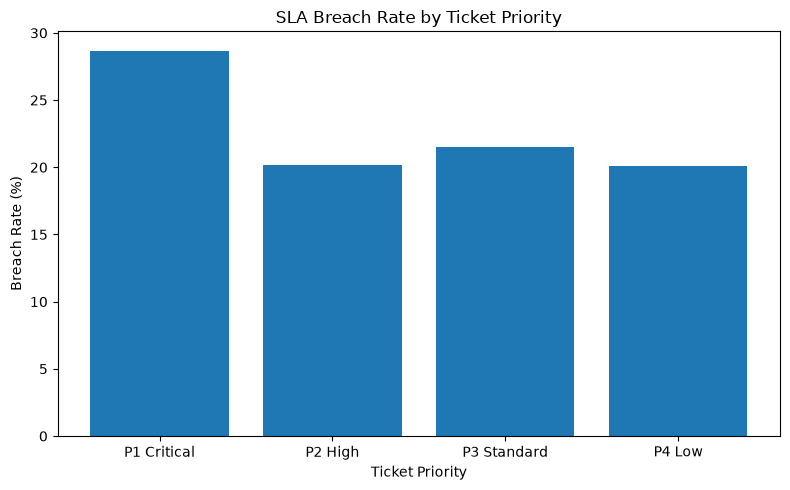

In [38]:
# Create a bar chart showing SLA breach rate by priority level
plt.figure(figsize=(8, 5))

plt.bar(
    priority_summary["PriorityLabel"],
    priority_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Ticket Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Breach Rate (%)")

# Improve chart readability
plt.xticks(rotation=0)
plt.tight_layout()

# Display the chart
plt.show()

The chart shows that `P1 Critical` tickets have the highest SLA breach rate at approximately **28.68%**.

The other priority levels have lower and fairly similar breach rates, ranging from about **20% to 22%**.

This suggests that critical tickets face a greater risk of SLA breach, possibly because they have much shorter response and resolution deadlines. Priority therefore appears to have a meaningful relationship with SLA breach risk and should be considered during modelling.

,CategoryName,TotalTickets,BreachedTickets,BreachRate
3,Document Request,415,101,24.337349
2,Complaint,306,74,24.183007
4,Insurance Query,706,154,21.813031
1,Billing Issue,873,180,20.618557
0,Appointment Change,1200,245,20.416667


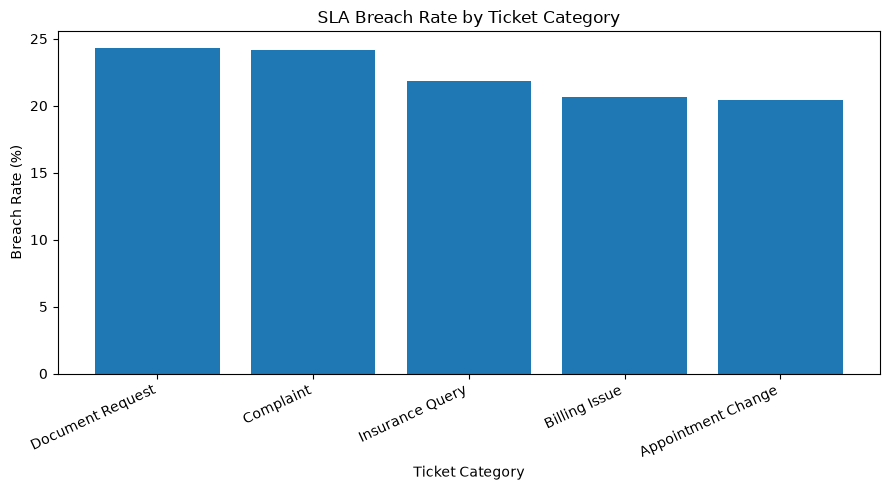

In [39]:
# Calculate SLA breach statistics for each ticket category
category_summary = model_data.groupby("CategoryName").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
category_summary["BreachRate"] = category_summary["BreachRate"] * 100

# Sort categories from highest to lowest breach rate
category_summary = category_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(category_summary)

# Create a bar chart showing SLA breach rate by ticket category
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["CategoryName"],
    category_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Ticket Category")
plt.xlabel("Ticket Category")
plt.ylabel("Breach Rate (%)")

# Rotate category labels for readability
plt.xticks(rotation=25, ha="right")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates show some variation across ticket categories.

- `Document Request` has the highest breach rate at approximately **24.34%**.
- `Complaint` follows closely at approximately **24.18%**.
- `Insurance Query` records a breach rate of approximately **21.81%**.
- `Billing Issue` and `Appointment Change` have the lowest breach rates at approximately **20.62%** and **20.42%**, respectively.

Although the differences between categories are moderate, Document Requests and Complaints appear more likely to breach SLA. This suggests that ticket category may provide useful information for predicting SLA breach risk.

,Channel,TotalTickets,BreachedTickets,BreachRate
2,Phone,905,216,23.867403
1,Form,397,89,22.418136
3,Portal,977,203,20.777892
0,Email,1221,246,20.147420


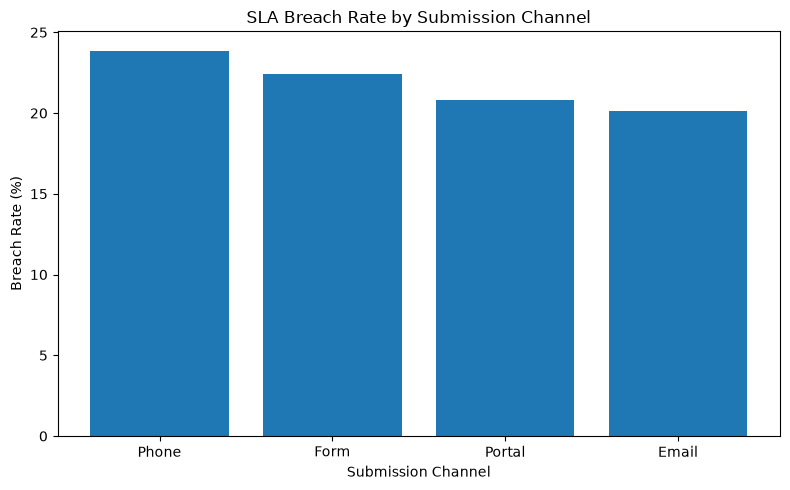

In [40]:
# Calculate SLA breach statistics for each submission channel
channel_summary = model_data.groupby("Channel").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
channel_summary["BreachRate"] = channel_summary["BreachRate"] * 100

# Sort channels from highest to lowest breach rate
channel_summary = channel_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(channel_summary)

# Create a bar chart showing SLA breach rate by submission channel
plt.figure(figsize=(8, 5))

plt.bar(
    channel_summary["Channel"],
    channel_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates differ across ticket submission channels.

- `Phone` has the highest breach rate at approximately **23.87%**.
- `Form` follows with a breach rate of approximately **22.42%**.
- `Portal` records a breach rate of approximately **20.78%**.
- `Email` has the lowest breach rate at approximately **20.15%**.

The differences are not extremely large, but tickets submitted by Phone and Form appear more likely to breach SLA than those submitted through Portal or Email.

This suggests that the submission channel may provide useful information for predicting SLA breach risk.

,ContractTier,TotalTickets,BreachedTickets,BreachRate
2,Standard,1662,364,21.901324
1,Premium,1295,277,21.389961
0,Enterprise,543,113,20.810313


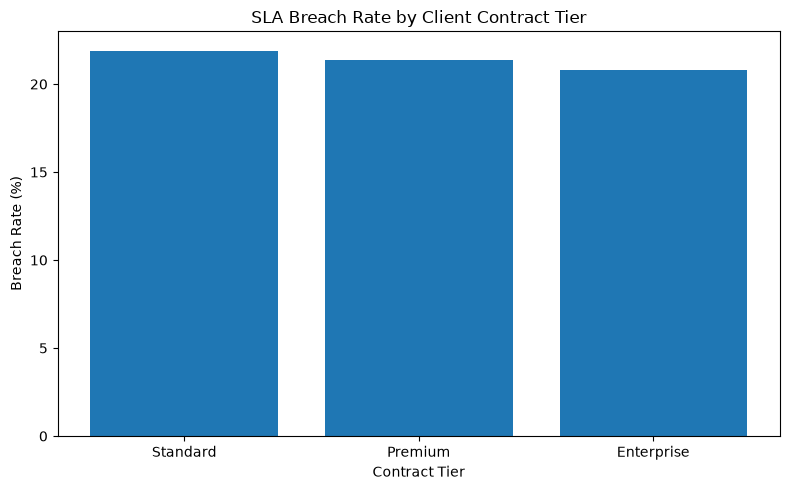

In [41]:
# Calculate SLA breach statistics for each contract tier
contract_summary = model_data.groupby("ContractTier").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
contract_summary["BreachRate"] = contract_summary["BreachRate"] * 100

# Sort contract tiers from highest to lowest breach rate
contract_summary = contract_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(contract_summary)

# Create a bar chart showing SLA breach rate by contract tier
plt.figure(figsize=(8, 5))

plt.bar(
    contract_summary["ContractTier"],
    contract_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Client Contract Tier")
plt.xlabel("Contract Tier")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates are relatively similar across the three client contract tiers.

- `Standard` clients have the highest breach rate at approximately **21.90%**.
- `Premium` clients record a breach rate of approximately **21.39%**.
- `Enterprise` clients have the lowest breach rate at approximately **20.81%**.

The differences between the contract tiers are small, suggesting that contract tier alone may not strongly separate breached and non-breached tickets.

However, contract tier still remains important because it determines the SLA response and resolution requirements for each ticket and may interact with other features such as ticket priority.

,Hub,TotalTickets,BreachedTickets,BreachRate
0,Birmingham,736,173,23.505435
3,Manchester,1346,312,23.179792
1,Edinburgh,817,156,19.094247
2,Leeds,601,113,18.801997


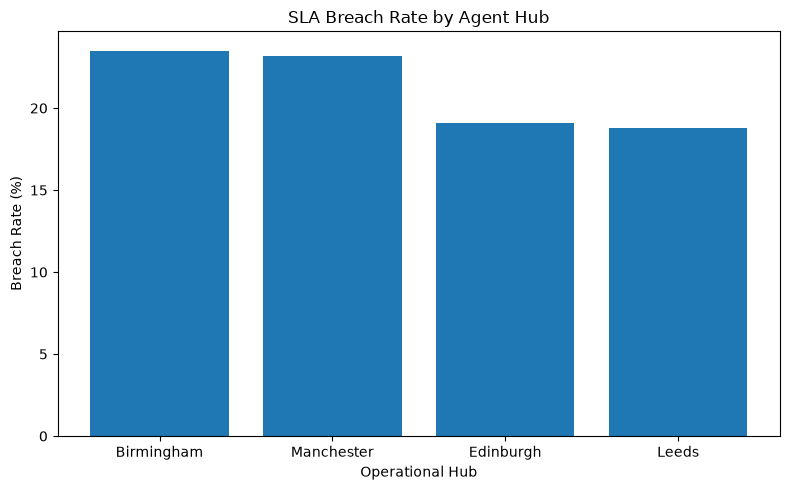

In [42]:
# Calculate SLA breach statistics for each operational hub
hub_summary = model_data.groupby("Hub").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
hub_summary["BreachRate"] = hub_summary["BreachRate"] * 100

# Sort hubs from highest to lowest breach rate
hub_summary = hub_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(hub_summary)

# Create a bar chart showing SLA breach rate by operational hub
plt.figure(figsize=(8, 5))

plt.bar(
    hub_summary["Hub"],
    hub_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Hub")
plt.xlabel("Operational Hub")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the four operational hubs.

- `Birmingham` has the highest breach rate at approximately **23.51%**.
- `Manchester` follows closely at approximately **23.18%**.
- `Edinburgh` records a lower breach rate of approximately **19.09%**.
- `Leeds` has the lowest breach rate at approximately **18.80%**.

The results suggest that tickets handled by Birmingham and Manchester experience higher SLA breach rates than those handled by Edinburgh and Leeds.

This may reflect differences in workload, staffing, capacity, or ticket mix across the hubs. However, the hub alone does not explain the cause of the breaches and should be considered alongside other operational features.

,DailyCapacity,TotalTickets,BreachedTickets,BreachRate
0,6,52,8,15.384615
1,8,63,13,20.634921
2,10,47,6,12.765957
3,11,24,6,25.000000
4,13,179,33,18.435754
5,14,215,50,23.255814
6,15,63,11,17.460317
7,16,96,23,23.958333
8,17,90,25,27.777778
9,18,331,73,22.054381


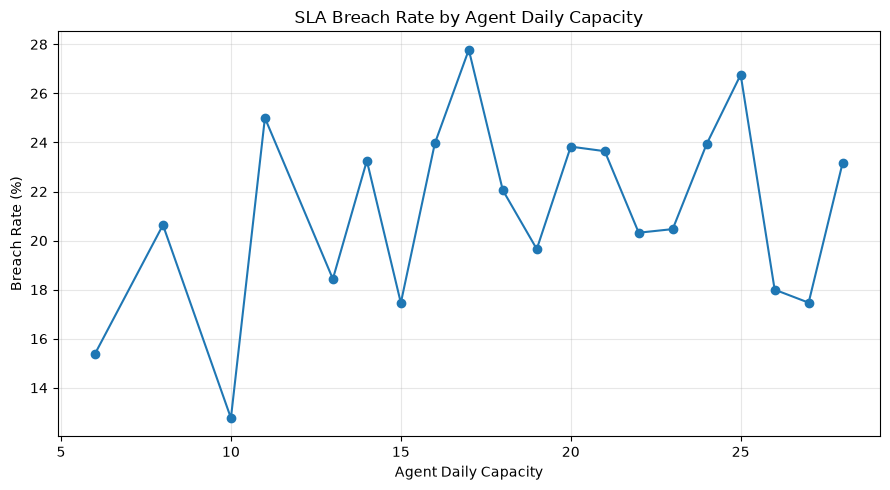

In [43]:
# Calculate SLA breach statistics for each agent daily capacity level
capacity_summary = model_data.groupby("DailyCapacity").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
capacity_summary["BreachRate"] = capacity_summary["BreachRate"] * 100

# Sort the results by daily capacity
capacity_summary = capacity_summary.sort_values("DailyCapacity")

# Display the summary table
display(capacity_summary)

# Create a line chart showing SLA breach rate across daily capacity levels
plt.figure(figsize=(9, 5))

plt.plot(
    capacity_summary["DailyCapacity"],
    capacity_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Daily Capacity")
plt.xlabel("Agent Daily Capacity")
plt.ylabel("Breach Rate (%)")

# Add a light grid to make the trend easier to read
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates fluctuate across different agent daily capacity levels, but there is no clear upward or downward trend.

Some capacity levels, such as 17 and 25 tickets per day, show relatively high breach rates, while others, such as 6, 10, 26, and 27 tickets per day, show lower breach rates.

However, several capacity levels have relatively small numbers of tickets, which can cause the breach rate to vary more sharply.

Overall, `DailyCapacity` alone does not appear to have a strong or consistent relationship with SLA breach risk. Its effect may be more meaningful when considered together with other operational factors such as ticket priority, hub, team, and actual workload.

,CreatedDayOfWeek,TotalTickets,BreachedTickets,BreachRate
1,Monday,468,101,21.581197
5,Tuesday,493,95,19.269777
6,Wednesday,512,105,20.507812
4,Thursday,473,101,21.353066
0,Friday,519,123,23.699422
2,Saturday,522,105,20.114943
3,Sunday,513,124,24.171540


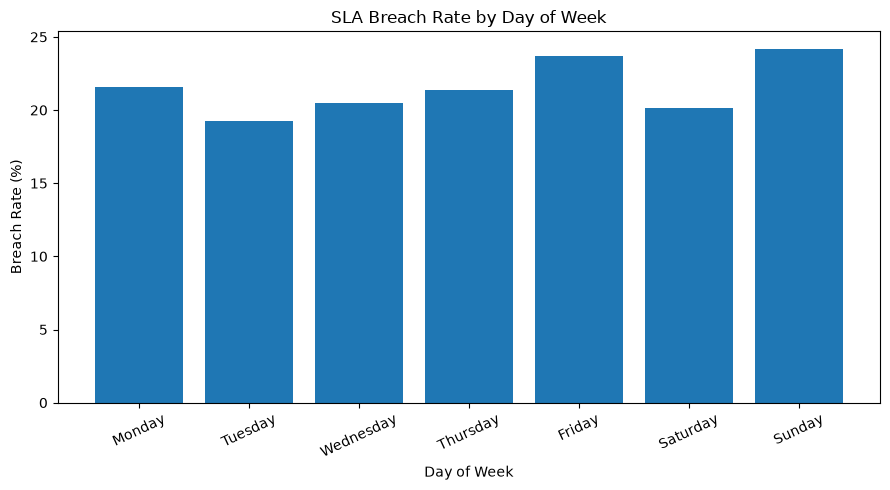

In [44]:
# Set the correct day-of-week order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate SLA breach statistics for each day of the week
day_summary = model_data.groupby("CreatedDayOfWeek").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
day_summary["BreachRate"] = day_summary["BreachRate"] * 100

# Convert the day column to an ordered category
day_summary["CreatedDayOfWeek"] = pd.Categorical(
    day_summary["CreatedDayOfWeek"],
    categories=day_order,
    ordered=True
)

# Sort the results in calendar order
day_summary = day_summary.sort_values("CreatedDayOfWeek")

# Display the summary table
display(day_summary)

# Create a bar chart showing SLA breach rate by day of week
plt.figure(figsize=(9, 5))

plt.bar(
    day_summary["CreatedDayOfWeek"].astype(str),
    day_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Breach Rate (%)")

# Rotate labels slightly for readability
plt.xticks(rotation=25)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the days of the week.

- `Sunday` has the highest breach rate at approximately **24.17%**.
- `Friday` follows at approximately **23.70%**.
- `Monday` and `Thursday` show moderate breach rates of approximately **21.58%** and **21.35%**.
- `Tuesday` records the lowest breach rate at approximately **19.27%**.
- `Wednesday` and `Saturday` fall in between at approximately **20.51%** and **20.11%**.

The pattern suggests that tickets created toward the end of the week, especially on Friday and Sunday, may face a slightly higher risk of SLA breach.

However, the differences are not extreme, so day of week is likely to be more useful when combined with other features rather than used on its own.

,CreatedHour,TotalTickets,BreachedTickets,BreachRate
0,0,130,27,20.769231
1,1,139,34,24.460432
2,2,148,23,15.540541
3,3,159,35,22.012579
4,4,136,26,19.117647
5,5,143,28,19.580420
6,6,130,26,20.000000
7,7,163,42,25.766871
8,8,151,31,20.529801
9,9,153,29,18.954248


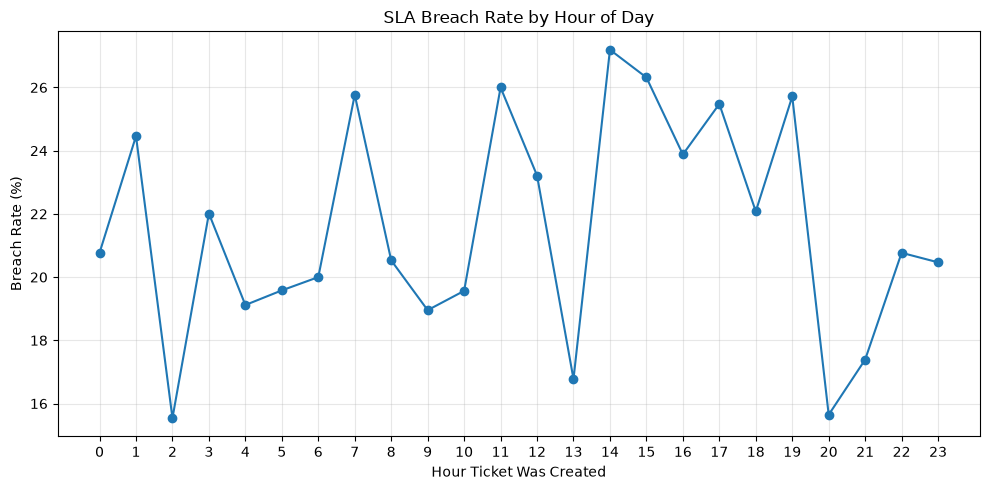

In [45]:
# Calculate SLA breach statistics for each ticket creation hour
hour_summary = model_data.groupby("CreatedHour").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
hour_summary["BreachRate"] = hour_summary["BreachRate"] * 100

# Sort the results by hour of day
hour_summary = hour_summary.sort_values("CreatedHour")

# Display the summary table
display(hour_summary)

# Create a line chart showing SLA breach rate by hour of day
plt.figure(figsize=(10, 5))

plt.plot(
    hour_summary["CreatedHour"],
    hour_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Hour of Day")
plt.xlabel("Hour Ticket Was Created")
plt.ylabel("Breach Rate (%)")

# Show each hour clearly on the x-axis
plt.xticks(range(0, 24))

# Add a light grid to make the pattern easier to read
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary noticeably depending on the hour a ticket was created.

- The highest breach rate occurs at `14:00` (2 PM) at approximately **27.19%**.
- Other relatively high breach rates appear around `15:00`, `11:00`, `7:00`, `17:00`, and `19:00`, ranging from about **25% to 26%**.
- Some of the lowest breach rates occur at `02:00`, `20:00`, `13:00`, and `21:00`.

There is no consistent increase or decrease in SLA breach rate throughout the day. Instead, the pattern fluctuates across different hours.

This suggests that ticket creation hour may contain useful predictive information, but its relationship with SLA breach risk is not linear and should be considered together with other features.

,CreatedMonth,TotalTickets,BreachedTickets,BreachRate
0,1,405,94,23.209877
1,2,352,78,22.159091
2,3,392,87,22.193878
3,4,268,57,21.268657
4,5,259,61,23.552124
5,6,261,50,19.157088
6,7,248,39,15.725806
7,8,289,67,23.183391
8,9,248,57,22.983871
9,10,269,61,22.676580


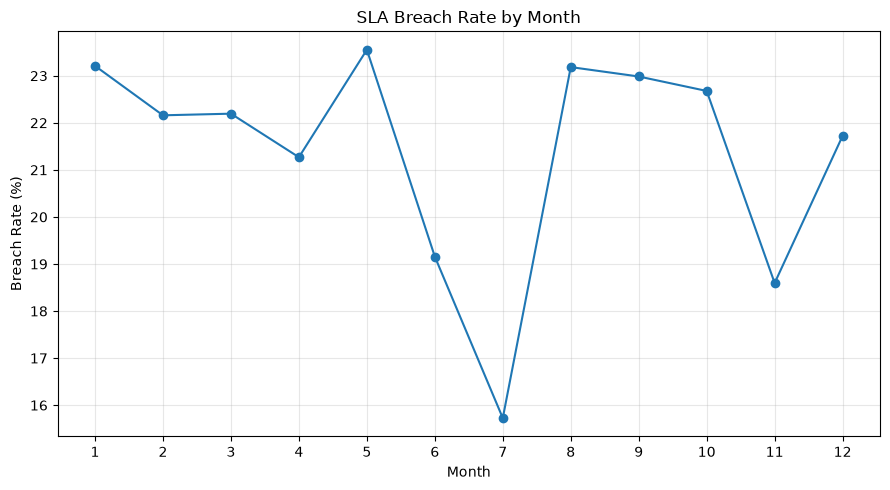

In [46]:
# Calculate SLA breach statistics for each creation month
month_summary = model_data.groupby("CreatedMonth").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
month_summary["BreachRate"] = month_summary["BreachRate"] * 100

# Sort the results by month number
month_summary = month_summary.sort_values("CreatedMonth")

# Display the summary table
display(month_summary)

# Create a line chart showing SLA breach rate by month
plt.figure(figsize=(9, 5))

plt.plot(
    month_summary["CreatedMonth"],
    month_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Month")
plt.xlabel("Month")
plt.ylabel("Breach Rate (%)")

# Show all month numbers clearly on the x-axis
plt.xticks(range(1, 13))

# Add a light grid for readability
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the months of the year.

- `May` records the highest breach rate at approximately **23.55%**.
- `January` and `August` also show relatively high breach rates at approximately **23.21%** and **23.18%**.
- `September` and `October` remain fairly high at around **23%**.
- `July` has the lowest breach rate at approximately **15.73%**.
- `November` and `June` also show relatively low breach rates at approximately **18.60%** and **19.16%**.

The results suggest that SLA breach risk changes across the year, with some months experiencing higher breach rates than others.

This indicates that month may contain useful predictive information, although the pattern should not be interpreted as a clear seasonal trend without further investigation into ticket volume and other operational factors.

,SLACreditClause,TotalTickets,BreachedTickets,BreachRate
0,No Credit Clause,2189,475,21.699406
1,Credit Clause,1311,279,21.281465


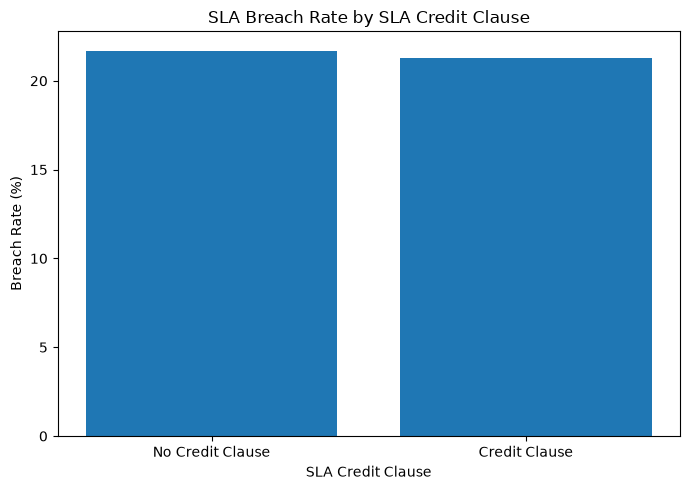

In [47]:
# Calculate SLA breach statistics by SLA credit clause
credit_summary = model_data.groupby("SLACreditClause").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
credit_summary["BreachRate"] = credit_summary["BreachRate"] * 100

# Replace the numeric values with readable labels
credit_summary["SLACreditClause"] = credit_summary["SLACreditClause"].map({
    0: "No Credit Clause",
    1: "Credit Clause"
})

# Display the summary table
display(credit_summary)

# Create a bar chart showing SLA breach rate by SLA credit clause
plt.figure(figsize=(7, 5))

plt.bar(
    credit_summary["SLACreditClause"],
    credit_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by SLA Credit Clause")
plt.xlabel("SLA Credit Clause")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates are almost the same for clients with and without an SLA credit clause.

- Clients with `No Credit Clause` have a breach rate of approximately **21.70%**.
- Clients with a `Credit Clause` have a breach rate of approximately **21.28%**.

The difference between the two groups is very small, suggesting that `SLACreditClause` by itself does not strongly separate breached and non-breached tickets.

However, the feature may still provide useful information when combined with other variables such as contract tier and ticket priority during modelling.

,TeamID,TotalTickets,BreachedTickets,BreachRate
2,6,736,173,23.505435
0,1,1346,312,23.179792
3,8,817,156,19.094247
1,4,601,113,18.801997


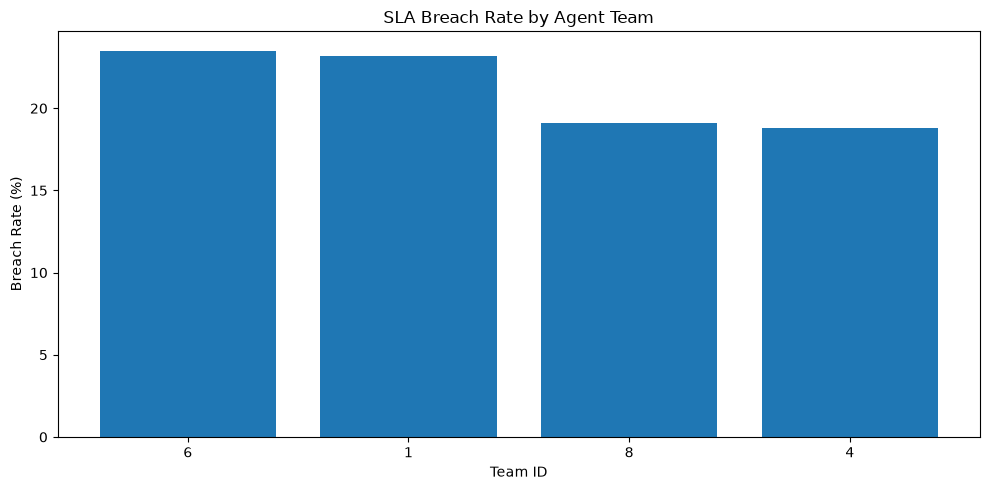

In [48]:
# Calculate SLA breach statistics for each team
team_summary = model_data.groupby("TeamID").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
team_summary["BreachRate"] = team_summary["BreachRate"] * 100

# Sort teams from highest to lowest breach rate
team_summary = team_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(team_summary)

# Create a bar chart showing SLA breach rate by team
plt.figure(figsize=(10, 5))

plt.bar(
    team_summary["TeamID"].astype(str),
    team_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Team")
plt.xlabel("Team ID")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across operational teams.

- `Team 6` has the highest breach rate at approximately **23.51%**.
- `Team 1` follows closely at approximately **23.18%**.
- `Team 8` records a lower breach rate of approximately **19.09%**.
- `Team 4` has the lowest breach rate at approximately **18.80%**.

The difference between the highest- and lowest-performing teams is noticeable, suggesting that team assignment may be associated with SLA breach risk.

However, these results should be interpreted together with hub, workload, ticket priority, and other operational factors, since team-level differences may reflect the type and volume of tickets handled rather than team performance alone.

In [49]:
# Check how many hubs are associated with each TeamID
team_hub_check = model_data.groupby("TeamID")["Hub"].nunique()

# Display the number of unique hubs linked to each team
team_hub_check

TeamID
1    1
4    1
6    1
8    1
Name: Hub, dtype: int64

In [50]:
# Display the actual TeamID and Hub combinations
team_hub_mapping = model_data[
    ["TeamID", "Hub"]
].drop_duplicates().sort_values("TeamID")

# View the team-to-hub mapping
team_hub_mapping

,TeamID,Hub
1,1,Manchester
2,4,Leeds
9,6,Birmingham
0,8,Edinburgh


Each operational team is associated with exactly one hub:

- `Team 1` → Manchester
- `Team 4` → Leeds
- `Team 6` → Birmingham
- `Team 8` → Edinburgh

This shows that `TeamID` and `Hub` contain overlapping information in this dataset.

Since both features represent the same operational grouping, including both in the model would introduce unnecessary redundancy. `Hub` will be preferred because it provides a more descriptive and interpretable representation of the operational location.

## Exploratory Data Analysis Summary

The exploratory analysis examined SLA breach patterns across ticket, client, agent, and time-based features.

The main findings are:

- `P1 Critical` tickets recorded the highest SLA breach rate at approximately **28.68%**, suggesting that ticket priority is an important indicator of breach risk.
- `Document Request` and `Complaint` tickets had the highest breach rates among ticket categories, at approximately **24%**.
- Tickets submitted through `Phone` had the highest breach rate at approximately **23.87%**, while `Email` had the lowest at approximately **20.15%**.
- SLA breach rates were very similar across client contract tiers, ranging from approximately **20.81% to 21.90%**.
- `Birmingham` and `Manchester` showed higher breach rates than `Edinburgh` and `Leeds`.
- `DailyCapacity` did not show a clear or consistent relationship with SLA breach risk when examined on its own.
- SLA breach rates varied across the week, with `Sunday` and `Friday` recording the highest rates.
- Ticket creation hour showed noticeable variation in breach rates, although there was no clear linear pattern across the day.
- Monthly breach rates also varied, with `May` among the highest and `July` recording the lowest rate.
- SLA credit clause status showed very little difference in breach rates between clients with and without a credit clause.
- `TeamID` and `Hub` were found to represent the same operational grouping, with each team belonging to exactly one hub. To avoid redundant information, `Hub` will be preferred over `TeamID` during modelling.

Overall, the analysis suggests that ticket priority, category, submission channel, hub, and time-related features may provide useful information for predicting SLA breach risk. Other variables such as contract tier, daily capacity, and SLA credit clause may have weaker individual relationships but could still contribute when combined with other features in the machine learning model.

### Model Preparation

In [51]:
# Select the features that will be used to predict SLA breach
features = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "SLACreditClause",
    "Hub",
    "DailyCapacity",
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth"
]

# Create the feature dataset X
X = model_data[features].copy()

# Create the target variable y
y = model_data["SLABreached"].copy()

# Check the dimensions of the feature and target datasets
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3500, 10)
y shape: (3500,)


In [52]:
# Preview the features selected for modelling
X.head()

,PriorityLabel,CategoryName,Channel,ContractTier,SLACreditClause,Hub,DailyCapacity,CreatedHour,CreatedDayOfWeek,CreatedMonth
0,P3 Standard,Document Request,Phone,Standard,0,Edinburgh,16,23,Wednesday,7
1,P1 Critical,Billing Issue,Portal,Standard,0,Manchester,8,23,Wednesday,11
2,P3 Standard,Insurance Query,Portal,Standard,0,Leeds,21,5,Thursday,8
3,P2 High,Appointment Change,Form,Premium,1,Manchester,27,13,Tuesday,12
4,P2 High,Insurance Query,Phone,Standard,0,Leeds,26,3,Saturday,2


In [53]:
# Confirm the distribution of the target variable
y.value_counts()

SLABreached
0    2746
1     754
Name: count, dtype: int64

The final modelling dataset contains **3,500 ticket records and 10 predictor features**.

The selected features include ticket characteristics, client contract information, agent operational information, and ticket creation time features. All selected variables are available before the final SLA outcome is known, helping to reduce the risk of data leakage.

The target variable remains moderately imbalanced:

- `0` (No SLA Breach): **2,746 tickets**
- `1` (SLA Breach): **754 tickets**

This imbalance will be considered when evaluating model performance, with greater attention given to metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

### Train/Test Split

In [54]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of the data will be used for training and 20% for testing
# Stratify=y keeps the SLA breach proportion similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the size of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2800, 10)
X_test shape: (700, 10)
y_train shape: (2800,)
y_test shape: (700,)


In [55]:
# Check SLA breach percentages in the training and testing sets
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
SLABreached
0    78.464286
1    21.535714
Name: proportion, dtype: float64

Testing target distribution:
SLABreached
0    78.428571
1    21.571429
Name: proportion, dtype: float64


The dataset was successfully divided into training and testing sets using an 80/20 split.

- The training set contains **2,800 records**.
- The testing set contains **700 records**.
- Both datasets contain the same 10 predictor features.

Stratification preserved the SLA breach distribution across both sets:

- Training set: approximately **21.54% breached** and **78.46% not breached**
- Testing set: approximately **21.57% breached** and **78.43% not breached**

This ensures that both datasets have a similar class distribution and provides a fair basis for model training and evaluation.

### Data Preprocessing

In [56]:
# Define categorical features that need One-Hot Encoding
categorical_features = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "Hub",
    "CreatedDayOfWeek"
]

# Define numerical features that will be standardised
numerical_features = [
    "DailyCapacity",
    "CreatedHour",
    "CreatedMonth"
]

# Define the binary feature
# This is already represented as 0 and 1, so no encoding is required
binary_features = [
    "SLACreditClause"
]

In [57]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        
        # Convert categorical features into numerical dummy variables
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        
        # Standardise numerical features
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        
        # Keep the binary feature unchanged
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

# Display the preprocessing setup
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

The preprocessing transformer was created successfully.

- Categorical features will be processed using `OneHotEncoder`.
- Numerical features will be standardised using `StandardScaler`.
- The binary `SLACreditClause` feature will be passed through without additional transformation.

This preprocessing setup will be included in the machine learning pipeline so that the same transformations are applied consistently during model training and testing.

### Baseline Model: Logistic Regression

In [58]:
# Import Logistic Regression and Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline
# The preprocessing step prepares the features before model training
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the baseline model using the training data
logistic_model.fit(X_train, y_train)

# Confirm that model training is complete
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [59]:
# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Generate predicted classes for the test data
y_pred = logistic_model.predict(X_test)

# Generate predicted probabilities for the positive class (SLA breach = 1)
# These probabilities are required for calculating ROC-AUC
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the main evaluation metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7843
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5198


c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
# Display the full classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       549
           1       0.00      0.00      0.00       151

    accuracy                           0.78       700
   macro avg       0.39      0.50      0.44       700
weighted avg       0.62      0.78      0.69       700



c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [61]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix values
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[549   0]
 [151   0]]


The baseline Logistic Regression model achieved an accuracy of approximately **78.43%**. However, the accuracy is misleading because the model predicted every test observation as a non-breached ticket.

The confusion matrix shows:

- **549 true negatives** – non-breached tickets correctly classified
- **0 false positives**
- **151 false negatives** – breached tickets incorrectly classified as non-breached
- **0 true positives** – no actual SLA breaches were identified

As a result, precision, recall, and F1-score for the SLA breach class are all **0**.

The ROC-AUC score of approximately **0.52** also indicates that the baseline model has very limited ability to distinguish between breached and non-breached tickets.

This demonstrates why accuracy alone is not an appropriate evaluation metric for this imbalanced classification problem. The baseline model provides a useful performance floor but requires improvement before it can support proactive SLA breach detection.

### Handle the class imbalance

In [62]:
# Create a class-weighted Logistic Regression pipeline
# class_weight="balanced" gives more importance to the minority SLA breach class
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train the class-weighted Logistic Regression model
balanced_logistic_model.fit(X_train, y_train)

# Confirm that training is complete
print("Class-weighted Logistic Regression model trained successfully.")

Class-weighted Logistic Regression model trained successfully.


In [63]:
# Generate class predictions using the class-weighted model
y_pred_balanced = balanced_logistic_model.predict(X_test)

# Generate predicted probabilities for SLA breach
y_prob_balanced = balanced_logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)
balanced_roc_auc = roc_auc_score(y_test, y_prob_balanced)

# Display the evaluation results
print(f"Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall:    {balanced_recall:.4f}")
print(f"F1-Score:  {balanced_f1:.4f}")
print(f"ROC-AUC:   {balanced_roc_auc:.4f}")

Accuracy:  0.5000
Precision: 0.2181
Recall:    0.5099
F1-Score:  0.3056
ROC-AUC:   0.5189


In [64]:
# Display the classification report for both classes
print(classification_report(
    y_test,
    y_pred_balanced,
    zero_division=0
))

# Create and display the confusion matrix
balanced_cm = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(balanced_cm)

              precision    recall  f1-score   support

           0       0.79      0.50      0.61       549
           1       0.22      0.51      0.31       151

    accuracy                           0.50       700
   macro avg       0.50      0.50      0.46       700
weighted avg       0.66      0.50      0.54       700

Confusion Matrix:
[[273 276]
 [ 74  77]]


Applying class weighting improved the model's ability to identify SLA breaches compared with the baseline Logistic Regression model.

The class-weighted model achieved:

- Accuracy: **50.00%**
- Precision: **21.81%**
- Recall: **50.99%**
- F1-score: **30.56%**
- ROC-AUC: **51.89%**

The model correctly identified **77 of the 151 actual SLA breaches**, increasing breach recall from 0% in the baseline model to approximately 51%.

However, this improvement came with a high number of false positives. The model incorrectly classified **276 non-breached tickets as SLA breaches**.

Although class weighting improved minority-class detection, the ROC-AUC remained close to 0.50, indicating that Logistic Regression still has limited ability to distinguish between breached and non-breached tickets.

Therefore, the class-weighted Logistic Regression model is not considered suitable as the final model, but it provides a useful benchmark for comparison with more advanced non-linear models.

### XGBoost Classification Model

In [65]:
# Import the XGBoost classifier
from xgboost import XGBClassifier

# Count the number of non-breached and breached tickets in the training set
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

# Calculate the class imbalance weight
# This tells XGBoost to give more importance to the minority breach class
scale_pos_weight = negative_count / positive_count

# Display the calculated weight
print("Scale Pos Weight:", round(scale_pos_weight, 2))

Scale Pos Weight: 3.64


In [66]:
# Create the XGBoost classification pipeline
# The same preprocessing steps are applied before training the model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        # Train an XGBoost classifier
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

# Train the XGBoost model using the training data
xgb_model.fit(X_train, y_train)

# Confirm that training is complete
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


The XGBoost model is evaluated using the same metrics applied to Logistic Regression.

Using the same evaluation measures allows the models to be compared fairly and helps determine whether the non-linear XGBoost model provides better detection of SLA breaches.

In [67]:
# Generate class predictions using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Generate predicted probabilities for SLA breach
# These probabilities are used to calculate ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

# Display the main evaluation metrics
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

Accuracy:  0.6157
Precision: 0.2318
Recall:    0.3377
F1-Score:  0.2749
ROC-AUC:   0.5211


In [68]:
# Display the full classification report

print(
    classification_report(
        y_test,
        y_pred_xgb,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.79      0.69      0.74       549
           1       0.23      0.34      0.27       151

    accuracy                           0.62       700
   macro avg       0.51      0.51      0.51       700
weighted avg       0.67      0.62      0.64       700



The XGBoost model achieved an accuracy of approximately **61.57%**, with a precision of **23.18%**, recall of **33.77%**, F1-score of **27.49%**, and ROC-AUC of **52.11%**.

Compared with the class-weighted Logistic Regression model, XGBoost improved accuracy and slightly improved precision. However, recall decreased from approximately 51% to 34%, meaning that XGBoost identified fewer of the actual SLA breaches.

The ROC-AUC score also remained close to 0.50, indicating that the model still has limited ability to distinguish between breached and non-breached tickets.

Therefore, XGBoost does not currently provide a strong improvement over the Logistic Regression benchmark. Further model comparison and feature improvement are required before selecting a final model.

### Initial Model Comparison

In [69]:
# Create a comparison table containing the evaluation results
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        balanced_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        balanced_recall,
        xgb_recall
    ],
    "F1-Score": [
        f1,
        balanced_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc,
        xgb_roc_auc
    ]
})

# Round the values to four decimal places for easier comparison
model_comparison = model_comparison.round(4)

# Display the model comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7843,0.0000,0.0000,0.0000,0.5198
1,Weighted Logistic Regression,0.5000,0.2181,0.5099,0.3056,0.5189
2,XGBoost,0.6157,0.2318,0.3377,0.2749,0.5211


The initial model comparison shows that none of the three models currently provides strong predictive performance.

- The baseline Logistic Regression achieved the highest accuracy at **78.43%**, but it failed to identify any SLA breaches, resulting in 0 precision, recall, and F1-score for the breach class.
- The class-weighted Logistic Regression achieved the highest recall at approximately **50.99%** and the highest F1-score at **30.56%**, making it better at identifying actual SLA breaches.
- XGBoost improved accuracy to **61.57%** and achieved the highest ROC-AUC at **52.11%**, but its recall was lower than the class-weighted Logistic Regression.

All ROC-AUC scores remain close to **0.50**, indicating that the current feature set has limited ability to separate breached and non-breached tickets.

The results suggest that improving the available predictive features may be more important than simply applying more complex algorithms.

### Additional Feature Engineering: SLA Time Window

In [70]:
# Convert SLADueAt to datetime format in the modelling dataset
# CreatedAt was already converted earlier
model_data["SLADueAt"] = pd.to_datetime(model_data["SLADueAt"])

# Calculate the total number of hours between ticket creation and the SLA deadline
model_data["SLAWindowHours"] = (
    model_data["SLADueAt"] - model_data["CreatedAt"]
).dt.total_seconds() / 3600

# Preview the new SLA time-window feature
model_data[
    [
        "CreatedAt",
        "SLADueAt",
        "PriorityLabel",
        "ContractTier",
        "SLAWindowHours"
    ]
].head()

,CreatedAt,SLADueAt,PriorityLabel,ContractTier,SLAWindowHours
0,2024-07-24 23:41:00,2024-07-27 23:41:00,P3 Standard,Standard,72.0
1,2024-11-06 23:45:00,2024-11-07 07:45:00,P1 Critical,Standard,8.0
2,2024-08-01 05:39:00,2024-08-04 05:39:00,P3 Standard,Standard,72.0
3,2024-12-03 13:22:00,2024-12-04 01:22:00,P2 High,Premium,12.0
4,2023-02-11 03:56:00,2023-02-12 03:56:00,P2 High,Standard,24.0


In [71]:
# Examine the distribution of the SLA time window
model_data["SLAWindowHours"].describe()

count    3500.000000
mean       48.454857
std        31.082646
min         2.000000
25%        24.000000
50%        48.000000
75%        72.000000
max       120.000000
Name: SLAWindowHours, dtype: float64

In [72]:
# Compare SLA breach rates across different SLA time windows
sla_window_summary = model_data.groupby("SLAWindowHours").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate to percentage
sla_window_summary["BreachRate"] = sla_window_summary["BreachRate"] * 100

# Sort by SLA window length
sla_window_summary = sla_window_summary.sort_values("SLAWindowHours")

# Display the summary
sla_window_summary

,SLAWindowHours,TotalTickets,BreachedTickets,BreachRate
0,2.0,32,4,12.500000
1,4.0,109,34,31.192661
2,8.0,234,55,23.504274
3,12.0,285,54,18.947368
4,24.0,750,167,22.266667
5,48.0,734,156,21.253406
6,72.0,1003,216,21.535394
7,96.0,167,33,19.760479
8,120.0,186,35,18.817204


The available SLA time window varies considerably across tickets, ranging from **2 hours to 120 hours**, with an average of approximately **48.45 hours**.

SLA breach rates also vary across the different time windows. Tickets with a `4-hour` SLA window recorded the highest breach rate at approximately **31.19%**, while most other SLA windows recorded breach rates between approximately 19% and 24%.

The shortest 2-hour SLA window recorded a lower breach rate of 12.50%, although this group contains relatively few tickets and should therefore be interpreted cautiously.

There is no simple pattern showing that shorter SLA windows always result in higher breach rates. However, `SLAWindowHours` directly represents the amount of time available to resolve a ticket and provides useful business information that is not explicitly represented by a single existing feature.

The feature will therefore be included in the next modelling iteration to assess whether it improves predictive performance when combined with the other ticket, client, agent, and time-based features.

In [73]:
# Update the modelling features to include the SLA time window
features_updated = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "SLACreditClause",
    "Hub",
    "DailyCapacity",
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth",
    "SLAWindowHours"
]

# Create the updated feature dataset
X_updated = model_data[features_updated].copy()

# Keep the same target variable
y_updated = model_data["SLABreached"].copy()

# Check the updated dataset dimensions
print("X shape:", X_updated.shape)
print("y shape:", y_updated.shape)

X shape: (3500, 11)
y shape: (3500,)


## Updated Train-Test Split

Following the addition of the `SLAWindowHours` feature, the modelling dataset is split again into training and testing sets.

The same 80/20 stratified split and `random_state=42` are maintained so that the updated models can be compared fairly with the earlier models.

In [74]:
# Split the updated dataset into training and testing sets
# 80% of the data is used for training and 20% for testing
# Stratification keeps the SLA breach proportion similar in both sets
X_train_updated, X_test_updated, y_train_updated, y_test_updated = train_test_split(
    X_updated,
    y_updated,
    test_size=0.20,
    random_state=42,
    stratify=y_updated
)

# Check the dimensions of the updated training and testing datasets
print("X_train shape:", X_train_updated.shape)
print("X_test shape:", X_test_updated.shape)
print("y_train shape:", y_train_updated.shape)
print("y_test shape:", y_test_updated.shape)

X_train shape: (2800, 11)
X_test shape: (700, 11)
y_train shape: (2800,)
y_test shape: (700,)


In [75]:
# Check the SLA breach distribution in the updated training set
print("Training target distribution:")
print(y_train_updated.value_counts(normalize=True) * 100)

# Check the SLA breach distribution in the updated testing set
print("\nTesting target distribution:")
print(y_test_updated.value_counts(normalize=True) * 100)

Training target distribution:
SLABreached
0    78.464286
1    21.535714
Name: proportion, dtype: float64

Testing target distribution:
SLABreached
0    78.428571
1    21.571429
Name: proportion, dtype: float64


## Updated Data Preprocessing

The preprocessing pipeline is updated to include the newly engineered `SLAWindowHours` feature.

Categorical variables are processed using One-Hot Encoding, while numerical variables, including the new SLA time-window feature, are standardised using Standard Scaling.

The binary `SLACreditClause` variable remains unchanged.

In [76]:
# Define categorical features that require One-Hot Encoding
categorical_features_updated = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "Hub",
    "CreatedDayOfWeek"
]

# Define numerical features that require standardisation
# SLAWindowHours is now included as a numerical feature
numerical_features_updated = [
    "DailyCapacity",
    "CreatedHour",
    "CreatedMonth",
    "SLAWindowHours"
]

# Define the binary feature
# It is already represented as 0 and 1
binary_features_updated = [
    "SLACreditClause"
]

In [77]:
# Create the updated preprocessing transformer
preprocessor_updated = ColumnTransformer(
    transformers=[
        
        # Convert categorical features into numerical dummy variables
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_updated
        ),

        # Standardise numerical features
        (
            "numerical",
            StandardScaler(),
            numerical_features_updated
        ),

        # Keep the binary feature unchanged
        (
            "binary",
            "passthrough",
            binary_features_updated
        )
    ]
)

# Display the updated preprocessing setup
preprocessor_updated

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

## Updated Model Training

The Logistic Regression and XGBoost models are retrained using the updated feature set, which now includes `SLAWindowHours`.

The same train-test split, preprocessing approach, and evaluation metrics are maintained so that the updated results can be compared fairly with the initial models.

In [78]:
# Create a new class-weighted Logistic Regression pipeline
# The updated preprocessor now includes SLAWindowHours
updated_balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_updated),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train the updated model using the new training dataset
updated_balanced_logistic_model.fit(
    X_train_updated,
    y_train_updated
)

# Confirm that training is complete
print("Updated Weighted Logistic Regression trained successfully.")

Updated Weighted Logistic Regression trained successfully.


In [79]:
# Generate predictions for the updated test dataset
y_pred_log_updated = updated_balanced_logistic_model.predict(
    X_test_updated
)

# Generate predicted probabilities for SLA breach
y_prob_log_updated = updated_balanced_logistic_model.predict_proba(
    X_test_updated
)[:, 1]

# Calculate evaluation metrics
log_updated_accuracy = accuracy_score(
    y_test_updated,
    y_pred_log_updated
)

log_updated_precision = precision_score(
    y_test_updated,
    y_pred_log_updated
)

log_updated_recall = recall_score(
    y_test_updated,
    y_pred_log_updated
)

log_updated_f1 = f1_score(
    y_test_updated,
    y_pred_log_updated
)

log_updated_roc_auc = roc_auc_score(
    y_test_updated,
    y_prob_log_updated
)

# Display the evaluation results
print(f"Accuracy:  {log_updated_accuracy:.4f}")
print(f"Precision: {log_updated_precision:.4f}")
print(f"Recall:    {log_updated_recall:.4f}")
print(f"F1-Score:  {log_updated_f1:.4f}")
print(f"ROC-AUC:   {log_updated_roc_auc:.4f}")

Accuracy:  0.5043
Precision: 0.2151
Recall:    0.4901
F1-Score:  0.2990
ROC-AUC:   0.5255


In [80]:
# Display the classification report
print(
    classification_report(
        y_test_updated,
        y_pred_log_updated,
        zero_division=0
    )
)

# Create and display the confusion matrix
log_updated_cm = confusion_matrix(
    y_test_updated,
    y_pred_log_updated
)

print("Confusion Matrix:")
print(log_updated_cm)

              precision    recall  f1-score   support

           0       0.78      0.51      0.62       549
           1       0.22      0.49      0.30       151

    accuracy                           0.50       700
   macro avg       0.50      0.50      0.46       700
weighted avg       0.66      0.50      0.55       700

Confusion Matrix:
[[279 270]
 [ 77  74]]


In [81]:
# Count the majority and minority classes in the updated training set
negative_count_updated = (y_train_updated == 0).sum()
positive_count_updated = (y_train_updated == 1).sum()

# Calculate the class imbalance weight for XGBoost
scale_pos_weight_updated = (
    negative_count_updated / positive_count_updated
)

# Display the calculated weight
print(
    "Scale Pos Weight:",
    round(scale_pos_weight_updated, 2)
)

Scale Pos Weight: 3.64


In [82]:
# Create the updated XGBoost pipeline
# The updated preprocessor includes SLAWindowHours
updated_xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_updated),

        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_updated,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

# Train the updated XGBoost model
updated_xgb_model.fit(
    X_train_updated,
    y_train_updated
)

# Confirm that training is complete
print("Updated XGBoost model trained successfully.")

Updated XGBoost model trained successfully.


In [83]:
# Generate class predictions
y_pred_xgb_updated = updated_xgb_model.predict(
    X_test_updated
)

# Generate predicted probabilities for SLA breach
y_prob_xgb_updated = updated_xgb_model.predict_proba(
    X_test_updated
)[:, 1]

# Calculate evaluation metrics
xgb_updated_accuracy = accuracy_score(
    y_test_updated,
    y_pred_xgb_updated
)

xgb_updated_precision = precision_score(
    y_test_updated,
    y_pred_xgb_updated
)

xgb_updated_recall = recall_score(
    y_test_updated,
    y_pred_xgb_updated
)

xgb_updated_f1 = f1_score(
    y_test_updated,
    y_pred_xgb_updated
)

xgb_updated_roc_auc = roc_auc_score(
    y_test_updated,
    y_prob_xgb_updated
)

# Display the results
print(f"Accuracy:  {xgb_updated_accuracy:.4f}")
print(f"Precision: {xgb_updated_precision:.4f}")
print(f"Recall:    {xgb_updated_recall:.4f}")
print(f"F1-Score:  {xgb_updated_f1:.4f}")
print(f"ROC-AUC:   {xgb_updated_roc_auc:.4f}")

Accuracy:  0.6071
Precision: 0.2257
Recall:    0.3377
F1-Score:  0.2706
ROC-AUC:   0.5346


In [84]:
# Display the classification report
print(
    classification_report(
        y_test_updated,
        y_pred_xgb_updated,
        zero_division=0
    )
)

# Create and display the confusion matrix
xgb_updated_cm = confusion_matrix(
    y_test_updated,
    y_pred_xgb_updated
)

print("Confusion Matrix:")
print(xgb_updated_cm)

              precision    recall  f1-score   support

           0       0.79      0.68      0.73       549
           1       0.23      0.34      0.27       151

    accuracy                           0.61       700
   macro avg       0.51      0.51      0.50       700
weighted avg       0.67      0.61      0.63       700

Confusion Matrix:
[[374 175]
 [100  51]]


The models were retrained after adding `SLAWindowHours` to determine whether the amount of time available before an SLA deadline improved breach prediction.

For the class-weighted Logistic Regression model, recall remained around 49%, while precision remained low at approximately 22%. The model continued to generate a large number of false-positive breach alerts.

The updated XGBoost model achieved approximately 61% accuracy, 23% precision, and 34% recall. Its performance was also very similar to the previous XGBoost model.

Overall, adding `SLAWindowHours` did not produce a meaningful improvement in predictive performance. Although the feature is operationally relevant, the available SLA window alone does not provide enough additional information to clearly distinguish breached from non-breached tickets.

This suggests that the main limitation is likely the predictive information available in the current feature set rather than the choice of modelling algorithm alone.

In [85]:
# Compare the original and updated model results
# This helps assess whether SLAWindowHours improved performance

updated_model_comparison = pd.DataFrame({
    "Model": [
        "Weighted Logistic Regression - Original",
        "Weighted Logistic Regression - Updated",
        "XGBoost - Original",
        "XGBoost - Updated"
    ],

    "Accuracy": [
        balanced_accuracy,
        log_updated_accuracy,
        xgb_accuracy,
        xgb_updated_accuracy
    ],

    "Precision": [
        balanced_precision,
        log_updated_precision,
        xgb_precision,
        xgb_updated_precision
    ],

    "Recall": [
        balanced_recall,
        log_updated_recall,
        xgb_recall,
        xgb_updated_recall
    ],

    "F1-Score": [
        balanced_f1,
        log_updated_f1,
        xgb_f1,
        xgb_updated_f1
    ],

    "ROC-AUC": [
        balanced_roc_auc,
        log_updated_roc_auc,
        xgb_roc_auc,
        xgb_updated_roc_auc
    ]
})

# Round the metrics for easier comparison
updated_model_comparison = updated_model_comparison.round(4)

# Display the comparison table
updated_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Weighted Logistic Regression - Original,0.5000,0.2181,0.5099,0.3056,0.5189
1,Weighted Logistic Regression - Updated,0.5043,0.2151,0.4901,0.2990,0.5255
2,XGBoost - Original,0.6157,0.2318,0.3377,0.2749,0.5211
3,XGBoost - Updated,0.6071,0.2257,0.3377,0.2706,0.5346


Adding `SLAWindowHours` produced a small improvement in ROC-AUC for both model types.

- Weighted Logistic Regression improved from approximately **0.519 to 0.526 ROC-AUC**.
- XGBoost improved from approximately **0.521 to 0.535 ROC-AUC**.

However, the improvement was limited. The updated Weighted Logistic Regression recorded slightly lower recall and F1-score than the original model, while the updated XGBoost model produced almost identical recall and a slightly lower F1-score.

The updated XGBoost model achieved the highest ROC-AUC among the models tested so far, but a value of approximately **0.53** still indicates weak separation between breached and non-breached tickets.

Overall, `SLAWindowHours` adds some predictive information but does not substantially improve model performance. This suggests that the main limitation may be the predictive signal available in the current dataset rather than model complexity alone.

In [86]:
# Import the LightGBM classifier
from lightgbm import LGBMClassifier

# Create the LightGBM modelling pipeline
# The updated preprocessing transformer is used so that
# SLAWindowHours is included in the model
lightgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_updated),

        # Train the LightGBM classifier
        # class_weight="balanced" gives more importance
        # to the minority SLA breach class
        ("classifier", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            num_leaves=15,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        ))
    ]
)

# Train the LightGBM model
lightgbm_model.fit(
    X_train_updated,
    y_train_updated
)

# Confirm successful training
print("LightGBM model trained successfully.")

LightGBM model trained successfully.


In [87]:
# Generate predicted classes
y_pred_lgbm = lightgbm_model.predict(
    X_test_updated
)

# Generate SLA breach probabilities
y_prob_lgbm = lightgbm_model.predict_proba(
    X_test_updated
)[:, 1]

# Calculate evaluation metrics
lgbm_accuracy = accuracy_score(
    y_test_updated,
    y_pred_lgbm
)

lgbm_precision = precision_score(
    y_test_updated,
    y_pred_lgbm
)

lgbm_recall = recall_score(
    y_test_updated,
    y_pred_lgbm
)

lgbm_f1 = f1_score(
    y_test_updated,
    y_pred_lgbm
)

lgbm_roc_auc = roc_auc_score(
    y_test_updated,
    y_prob_lgbm
)

# Display the results
print(f"Accuracy:  {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall:    {lgbm_recall:.4f}")
print(f"F1-Score:  {lgbm_f1:.4f}")
print(f"ROC-AUC:   {lgbm_roc_auc:.4f}")

Accuracy:  0.6014
Precision: 0.2440
Recall:    0.4040
F1-Score:  0.3042
ROC-AUC:   0.5150


In [88]:
# Display the classification report
print(
    classification_report(
        y_test_updated,
        y_pred_lgbm,
        zero_division=0
    )
)

# Create and display the confusion matrix
lgbm_cm = confusion_matrix(
    y_test_updated,
    y_pred_lgbm
)

print("Confusion Matrix:")
print(lgbm_cm)

              precision    recall  f1-score   support

           0       0.80      0.66      0.72       549
           1       0.24      0.40      0.30       151

    accuracy                           0.60       700
   macro avg       0.52      0.53      0.51       700
weighted avg       0.68      0.60      0.63       700

Confusion Matrix:
[[360 189]
 [ 90  61]]


The LightGBM model achieved:

- Accuracy: **60.14%**
- Precision: **24.40%**
- Recall: **40.40%**
- F1-score: **30.42%**
- ROC-AUC: **51.50%**

LightGBM correctly identified 61 of the 151 breached tickets. However, it missed 90 actual breaches and incorrectly flagged 189 non-breached tickets.

Compared with XGBoost, LightGBM achieved higher precision, recall, and F1-score at the default classification threshold. However, its ROC-AUC remained close to 0.50, indicating weak overall separation between breached and non-breached tickets.

Therefore, LightGBM provides some improvement in breach detection at the chosen threshold but does not demonstrate strong predictive performance overall.

In [89]:
# Create the final comparison table for the main models tested
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Updated Weighted Logistic Regression",
        "Updated XGBoost",
        "LightGBM"
    ],

    "Accuracy": [
        accuracy,
        balanced_accuracy,
        log_updated_accuracy,
        xgb_updated_accuracy,
        lgbm_accuracy
    ],

    "Precision": [
        precision,
        balanced_precision,
        log_updated_precision,
        xgb_updated_precision,
        lgbm_precision
    ],

    "Recall": [
        recall,
        balanced_recall,
        log_updated_recall,
        xgb_updated_recall,
        lgbm_recall
    ],

    "F1-Score": [
        f1,
        balanced_f1,
        log_updated_f1,
        xgb_updated_f1,
        lgbm_f1
    ],

    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc,
        log_updated_roc_auc,
        xgb_updated_roc_auc,
        lgbm_roc_auc
    ]
})

# Round the results for easier comparison
final_model_comparison = final_model_comparison.round(4)

# Display the final model comparison
final_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.7843,0.0000,0.0000,0.0000,0.5198
1,Weighted Logistic Regression,0.5000,0.2181,0.5099,0.3056,0.5189
2,Updated Weighted Logistic Regression,0.5043,0.2151,0.4901,0.2990,0.5255
3,Updated XGBoost,0.6071,0.2257,0.3377,0.2706,0.5346
4,LightGBM,0.6014,0.2440,0.4040,0.3042,0.5150


### Final Model Comparison Summary

The final comparison shows that none of the models achieved strong SLA breach discrimination with the current feature set.

The baseline Logistic Regression produced the highest accuracy at **78.43%**, but this result was misleading because the model predicted every ticket as non-breached and failed to identify any actual SLA breaches.

The class-weighted Logistic Regression achieved the strongest breach detection performance, with approximately **50.99% recall** and the highest F1-score of **30.56%**. However, its low precision indicates that many non-breached tickets were incorrectly flagged as high risk.

The updated XGBoost model achieved the highest ROC-AUC at approximately **53.46%**, but its recall remained relatively low at **33.77%**.

LightGBM achieved the highest precision at **24.40%** and approximately **40.40% recall**, but its ROC-AUC remained close to random classification at **51.50%**.

Overall, the models show limited ability to distinguish between breached and non-breached tickets. This suggests that the primary limitation is likely the predictive information available in the current features rather than the choice of machine learning algorithm alone. Additional investigation of the SLA breach target and operational variables is therefore required before further model tuning.

## SLA Breach Target Validation

Before further model tuning, the SLA breach target is examined to understand how closely it relates to the recorded SLA deadline and ticket resolution time.

For resolved tickets, a breach would normally be expected when the resolution timestamp occurs after the SLA deadline. Comparing this derived outcome with the recorded `SLABreached` value helps validate the target and identify whether additional operational information may be required for prediction.

In [90]:
# Select only tickets that have already been resolved
resolved_tickets = tickets[
    tickets["ResolvedAt"].notna()
].copy()

# Derive an SLA breach indicator from the timestamps
# A ticket is considered breached if it was resolved after its SLA deadline
resolved_tickets["DerivedSLABreach"] = (
    resolved_tickets["ResolvedAt"] > resolved_tickets["SLADueAt"]
).astype(int)

# Compare the recorded SLA breach value with the derived value
target_validation = pd.crosstab(
    resolved_tickets["SLABreached"],
    resolved_tickets["DerivedSLABreach"],
    rownames=["Recorded SLABreached"],
    colnames=["Derived SLA Breach"]
)

# Display the comparison
target_validation

Derived SLA Breach,0,1
Recorded SLABreached,,
0,2624,0
1,0,677


In [91]:
# Calculate how often the recorded and derived breach labels agree
target_agreement = (
    resolved_tickets["SLABreached"]
    == resolved_tickets["DerivedSLABreach"]
).mean() * 100

# Display the agreement percentage
print(f"Target agreement: {target_agreement:.2f}%")

Target agreement: 100.00%


The recorded `SLABreached` target was validated against the ticket resolution and SLA deadline timestamps for all resolved tickets.

The derived SLA breach status matched the recorded target in **100% of resolved cases**:

- 2,624 tickets were correctly recorded as non-breached.
- 677 tickets were correctly recorded as breached.
- No inconsistencies were found between the recorded and timestamp-derived breach outcomes.

This confirms that the `SLABreached` target is reliable and correctly represents whether a resolved ticket exceeded its SLA deadline.

The weak predictive performance observed across the machine learning models is therefore not caused by incorrect target labels. Instead, it suggests that the features available at ticket creation contain limited information about the eventual resolution outcome.

In [92]:
# Calculate the number of hours taken to resolve each completed ticket
# This feature is created only for diagnostic analysis
resolved_tickets["ResolutionHours"] = (
    resolved_tickets["ResolvedAt"] - resolved_tickets["CreatedAt"]
).dt.total_seconds() / 3600

# Summarise resolution time for breached and non-breached tickets
resolution_summary = resolved_tickets.groupby("SLABreached")[
    "ResolutionHours"
].describe()

# Display the comparison
resolution_summary

,count,mean,std,min,25%,50%,75%,max
SLABreached,,,,,,,,
0,2624.0,30.150229,22.158274,0.633333,11.433333,25.583333,43.120833,110.900000
1,677.0,82.351526,56.608446,2.866667,34.200000,76.750000,117.366667,290.133333


In [93]:
# Calculate the average SLA window for breached and non-breached tickets
sla_resolution_comparison = resolved_tickets.groupby("SLABreached").agg(
    AverageResolutionHours=("ResolutionHours", "mean"),
    MedianResolutionHours=("ResolutionHours", "median"),
    AverageSLAWindowHours=(
        "SLADueAt",
        lambda x: (
            x - resolved_tickets.loc[x.index, "CreatedAt"]
        ).dt.total_seconds().mean() / 3600
    )
)

# Display the results
sla_resolution_comparison

,AverageResolutionHours,MedianResolutionHours,AverageSLAWindowHours
SLABreached,,,
0,30.150229,25.583333,48.790396
1,82.351526,76.750000,46.983752


A clear difference exists between the resolution times of breached and non-breached tickets.

- Non-breached tickets were resolved in approximately **30.15 hours on average**, with a median resolution time of **25.58 hours**.
- Breached tickets took approximately **82.35 hours on average**, with a median resolution time of **76.75 hours**.

In comparison, the average SLA time window was relatively similar between the two groups:

- Non-breached tickets: approximately **48.79 hours**
- Breached tickets: approximately **46.98 hours**

This indicates that SLA breaches are driven more strongly by how long tickets remain unresolved than by major differences in the SLA time allocated to them.

The current prediction features mainly describe the ticket at creation, such as priority, category, channel, client contract, assigned hub, and creation time. They contain limited information about what happens during ticket processing.

This helps explain why Logistic Regression, XGBoost, and LightGBM achieved weak predictive performance. Stronger early-warning predictions may require operational features that capture ticket progress, escalation activity, queue delays, reassignment, or current workload.

`ResolutionHours` will not be used as a predictive feature because it is only known after resolution and would introduce data leakage.

In [94]:
# Load the operational event tables
ticket_audit_log = pd.read_excel(
    file_path,
    sheet_name="TicketAuditLog"
)

escalation_log = pd.read_excel(
    file_path,
    sheet_name="EscalationLog"
)

# Check the size of each table
print("Ticket Audit Log:", ticket_audit_log.shape)
print("Escalation Log:", escalation_log.shape)

Ticket Audit Log: (17751, 8)
Escalation Log: (464, 7)


In [95]:
# Inspect the TicketAuditLog structure
# This shows the column names, data types, and missing values
ticket_audit_log.info()

<class 'pandas.DataFrame'>
RangeIndex: 17751 entries, 0 to 17750
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   LogID          17751 non-null  int64
 1   TicketID       17751 non-null  int64
 2   ActionType     17751 non-null  str  
 3   ActionByID     17751 non-null  int64
 4   ActionAt       17751 non-null  str  
 5   PreviousValue  14251 non-null  str  
 6   NewValue       17751 non-null  str  
 7   Notes          17751 non-null  str  
dtypes: int64(3), str(5)
memory usage: 1.1 MB


In [96]:
# Preview the first few TicketAuditLog records
ticket_audit_log.head()

,LogID,TicketID,ActionType,ActionByID,ActionAt,PreviousValue,NewValue,Notes
0,1,1,Created,111,2024-07-24 23:41,NaN,Open,Ticket created via Phone
1,2,1,Assigned,111,2024-07-24 23:55,Unassigned,Agent 111,Auto-routed by category specialism match
2,3,1,Responded,111,2024-07-25 02:27,Open,In Progress,Initial response sent to client
3,4,1,Status Changed,111,2024-07-25 23:27,In Progress,In Progress,Pending document verification
4,5,1,Resolved,111,2024-07-27 10:35,In Progress,Resolved,Resolution confirmed. Notes added.


In [97]:
# Inspect the EscalationLog structure
# This helps identify what escalation information is available
escalation_log.info()

<class 'pandas.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   EscalationID      464 non-null    int64
 1   TicketID          464 non-null    int64
 2   EscalatedFrom     464 non-null    int64
 3   EscalatedTo       464 non-null    int64
 4   EscalationReason  464 non-null    str  
 5   EscalatedAt       464 non-null    str  
 6   AutomatedFlag     464 non-null    int64
dtypes: int64(5), str(2)
memory usage: 25.5 KB


In [98]:
# Preview the first few EscalationLog records
escalation_log.head()

,EscalationID,TicketID,EscalatedFrom,EscalatedTo,EscalationReason,EscalatedAt,AutomatedFlag
0,1,39,108,105,SLA Risk,2023-10-10 19:58,0
1,2,107,105,111,SLA Risk,2023-04-25 23:41,0
2,3,129,38,31,SLA Risk,2024-12-17 02:05,0
3,4,275,68,69,SLA Risk,2025-03-16 22:24,1
4,5,321,82,86,SLA Risk,2023-10-09 10:12,1


In [99]:
# Check missing values in the TicketAuditLog table
print("TicketAuditLog missing values:")
display(ticket_audit_log.isnull().sum())

# Check missing values in the EscalationLog table
print("EscalationLog missing values:")
display(escalation_log.isnull().sum())

TicketAuditLog missing values:


LogID               0
TicketID            0
ActionType          0
ActionByID          0
ActionAt            0
PreviousValue    3500
NewValue            0
Notes               0
dtype: int64

EscalationLog missing values:


EscalationID        0
TicketID            0
EscalatedFrom       0
EscalatedTo         0
EscalationReason    0
EscalatedAt         0
AutomatedFlag       0
dtype: int64

The `TicketAuditLog` contains 17,751 operational events across the ticket lifecycle, while the `EscalationLog` contains 464 recorded escalation events.

The audit log captures activities such as ticket creation, assignment, response, status changes, and resolution. This provides richer information about how tickets progress after creation.

The escalation log contains information about escalation timing, escalation reason, agent reassignment, and whether the escalation was automated.

The only missing values were found in `TicketAuditLog.PreviousValue`, with 3,500 missing records. These may correspond to the initial ticket creation events, where no previous value exists, and will be investigated before any cleaning decision is made.

These operational tables may contain stronger predictors of SLA breach than the static ticket features used in the initial models. However, only events that occurred before the prediction time can be used for modelling to avoid data leakage.

In [100]:
# Check the different types of actions recorded in the audit log
# This helps us understand how tickets move through their lifecycle
print("Audit Action Types:")
print(ticket_audit_log["ActionType"].value_counts())

Audit Action Types:
ActionType
Created           3500
Assigned          3500
Responded         3454
Resolved          3301
Status Changed    2012
Closed            1984
Name: count, dtype: int64


In [101]:
# Check the different reasons tickets were escalated
print("Escalation Reasons:")
print(escalation_log["EscalationReason"].value_counts())

# Check how many escalations were automated or manual
print("\nAutomated Escalation Flag:")
print(escalation_log["AutomatedFlag"].value_counts())

Escalation Reasons:
EscalationReason
SLA Risk          420
Complexity         16
Client Request     13
Complaint           9
Regulatory          6
Name: count, dtype: int64

Automated Escalation Flag:
AutomatedFlag
0    233
1    231
Name: count, dtype: int64


In [102]:
# Check which action types contain missing PreviousValue
# This determines whether the missing values are expected operationally
ticket_audit_log.loc[
    ticket_audit_log["PreviousValue"].isnull(),
    "ActionType"
].value_counts()

ActionType
Created    3500
Name: count, dtype: int64

In [103]:
# Check how many unique tickets appear in each operational table
print(
    "Tickets represented in Audit Log:",
    ticket_audit_log["TicketID"].nunique()
)

print(
    "Tickets represented in Escalation Log:",
    escalation_log["TicketID"].nunique()
)

Tickets represented in Audit Log: 3500
Tickets represented in Escalation Log: 464


The operational event tables are internally consistent with the main Tickets table.

All 3,500 tickets appear in the TicketAuditLog and contain both a creation and assignment event. A total of 3,454 tickets contain a response event, while 3,301 contain a resolution event, which is consistent with the unresolved and unanswered tickets identified during earlier data validation.

The 3,500 missing values in `PreviousValue` occur only for `Created` events. Since a newly created ticket has no previous status or value, these missing records represent valid operational missingness and do not require treatment.

The EscalationLog contains 464 tickets, with `SLA Risk` accounting for the majority of escalation reasons. Manual and automated escalations are almost evenly distributed.

These event tables may provide useful information about ticket progress and emerging SLA risk. However, the timing of each event must be validated before any operational feature is used for prediction to avoid including information that occurred after the prediction point.

### Operational Event Timing Validation

Before operational events are used as predictive features, their timestamps are compared with the ticket creation and SLA deadline timestamps.

This helps determine whether events such as responses, status changes, and escalations occurred early enough to be legitimately available for an SLA risk prediction.

In [104]:
# Convert audit event timestamps from text to datetime format
ticket_audit_log["ActionAt"] = pd.to_datetime(
    ticket_audit_log["ActionAt"]
)

# Convert escalation timestamps from text to datetime format
escalation_log["EscalatedAt"] = pd.to_datetime(
    escalation_log["EscalatedAt"]
)

# Confirm the conversions
print("Audit timestamp type:", ticket_audit_log["ActionAt"].dtype)
print("Escalation timestamp type:", escalation_log["EscalatedAt"].dtype)

Audit timestamp type: datetime64[us]
Escalation timestamp type: datetime64[us]


In [105]:
# Add ticket creation and SLA deadline information to the audit log
audit_timing = ticket_audit_log.merge(
    tickets[
        [
            "TicketID",
            "CreatedAt",
            "SLADueAt"
        ]
    ],
    on="TicketID",
    how="left"
)

# Add ticket creation and SLA deadline information to the escalation log
escalation_timing = escalation_log.merge(
    tickets[
        [
            "TicketID",
            "CreatedAt",
            "SLADueAt"
        ]
    ],
    on="TicketID",
    how="left"
)

# Check whether any audit events occurred before ticket creation
audit_before_creation = (
    audit_timing["ActionAt"] < audit_timing["CreatedAt"]
).sum()

# Check whether any escalation events occurred before ticket creation
escalation_before_creation = (
    escalation_timing["EscalatedAt"]
    < escalation_timing["CreatedAt"]
).sum()

print("Audit events before ticket creation:", audit_before_creation)
print("Escalations before ticket creation:", escalation_before_creation)

Audit events before ticket creation: 0
Escalations before ticket creation: 0


In [106]:
# Determine whether each escalation happened before or after the SLA deadline
escalation_timing["EscalatedBeforeSLADue"] = (
    escalation_timing["EscalatedAt"]
    <= escalation_timing["SLADueAt"]
)

# Count escalations occurring before and after the SLA deadline
print(
    escalation_timing["EscalatedBeforeSLADue"].value_counts()
)

# Display the same result as percentages
print("\nPercentage:")
print(
    escalation_timing["EscalatedBeforeSLADue"]
    .value_counts(normalize=True)
    * 100
)

EscalatedBeforeSLADue
True     359
False    105
Name: count, dtype: int64

Percentage:
EscalatedBeforeSLADue
True     77.37069
False    22.62931
Name: proportion, dtype: float64


The operational event timestamps were successfully converted to datetime format and validated against ticket creation times.

No audit or escalation events occurred before the corresponding ticket was created, confirming that the event timestamps are logically consistent.

Of the 464 escalation events:

- **359 escalations (77.37%)** occurred before the SLA deadline.
- **105 escalations (22.63%)** occurred after the SLA deadline.

This shows that escalation information may provide useful early warning signals for SLA breach prediction.

However, simply using all events that occurred before the SLA deadline could still introduce information that becomes available too late for meaningful intervention. A fixed prediction checkpoint is therefore required so that only operational information available sufficiently early in the ticket lifecycle is used.

## Early-Warning Prediction Checkpoint

To simulate proactive SLA risk prediction, a prediction checkpoint is defined at **50% of each ticket's SLA time window**.

Only operational events that occurred on or before this checkpoint will be used to create predictive features.

Using a relative checkpoint instead of a fixed number of hours allows the approach to account for different SLA windows across ticket priorities and contract tiers.

For example, a ticket with a 24-hour SLA window will be evaluated after 12 hours, while a ticket with an 8-hour SLA window will be evaluated after 4 hours.

This approach prevents the model from using information that becomes available too close to, or after, the SLA deadline.

In [107]:
# Calculate the midpoint of each ticket's SLA window
# This represents the time when the early-warning prediction will be made
model_data["PredictionCheckpoint"] = (
    model_data["CreatedAt"]
    + (model_data["SLADueAt"] - model_data["CreatedAt"]) * 0.50
)

# Preview the prediction checkpoint
model_data[
    [
        "CreatedAt",
        "SLADueAt",
        "SLAWindowHours",
        "PredictionCheckpoint"
    ]
].head()

,CreatedAt,SLADueAt,SLAWindowHours,PredictionCheckpoint
0,2024-07-24 23:41:00,2024-07-27 23:41:00,72.0,2024-07-26 11:41:00
1,2024-11-06 23:45:00,2024-11-07 07:45:00,8.0,2024-11-07 03:45:00
2,2024-08-01 05:39:00,2024-08-04 05:39:00,72.0,2024-08-02 17:39:00
3,2024-12-03 13:22:00,2024-12-04 01:22:00,12.0,2024-12-03 19:22:00
4,2023-02-11 03:56:00,2023-02-12 03:56:00,24.0,2023-02-11 15:56:00


In [108]:
# Add the prediction checkpoint to the audit log
audit_checkpoint = ticket_audit_log.merge(
    model_data[
        [
            "TicketID",
            "PredictionCheckpoint"
        ]
    ],
    on="TicketID",
    how="left"
)

# Keep only audit events that occurred on or before the prediction checkpoint
audit_early = audit_checkpoint[
    audit_checkpoint["ActionAt"]
    <= audit_checkpoint["PredictionCheckpoint"]
].copy()

# Check how many early audit events remain
print("Audit events before checkpoint:", len(audit_early))
print(
    "Tickets represented:",
    audit_early["TicketID"].nunique()
)

Audit events before checkpoint: 12560
Tickets represented: 3500


In [109]:
# Add the prediction checkpoint to the escalation log
escalation_checkpoint = escalation_log.merge(
    model_data[
        [
            "TicketID",
            "PredictionCheckpoint"
        ]
    ],
    on="TicketID",
    how="left"
)

# Keep only escalations that occurred on or before the prediction checkpoint
escalation_early = escalation_checkpoint[
    escalation_checkpoint["EscalatedAt"]
    <= escalation_checkpoint["PredictionCheckpoint"]
].copy()

# Check how many early escalation events remain
print("Escalations before checkpoint:", len(escalation_early))
print(
    "Tickets escalated before checkpoint:",
    escalation_early["TicketID"].nunique()
)

Escalations before checkpoint: 0
Tickets escalated before checkpoint: 0


At the 50% SLA prediction checkpoint, 12,560 audit events were available across all 3,500 tickets.

This confirms that useful ticket activity occurs during the first half of the SLA window and can potentially be used to create dynamic operational features.

However, no escalation events occurred before the 50% checkpoint. Therefore, escalation-related variables would contain no variation at this prediction point and would not provide useful information to the model.

The early-warning model will therefore focus first on ticket audit activity such as assignment, response, and status changes.

In [110]:
# Check the types of audit events available before the prediction checkpoint
# This helps identify which operational events can be used for feature engineering
print("Audit actions available before checkpoint:")

print(
    audit_early["ActionType"].value_counts()
)

Audit actions available before checkpoint:
ActionType
Created           3500
Assigned          3500
Responded         3422
Status Changed    1285
Resolved           825
Closed              28
Name: count, dtype: int64


In [111]:
# Identify tickets that received a response before the prediction checkpoint
responded_before_checkpoint = audit_early[
    audit_early["ActionType"] == "Responded"
]["TicketID"].nunique()

# Calculate the percentage of all tickets that were responded to before the checkpoint
responded_percentage = (
    responded_before_checkpoint
    / model_data["TicketID"].nunique()
) * 100

print(
    "Tickets responded to before checkpoint:",
    responded_before_checkpoint
)

print(
    f"Percentage responded before checkpoint: "
    f"{responded_percentage:.2f}%"
)

Tickets responded to before checkpoint: 3422
Percentage responded before checkpoint: 97.77%


In [112]:
# Count the number of status-change events available before the checkpoint
status_changes_before_checkpoint = audit_early[
    audit_early["ActionType"] == "Status Changed"
]

print(
    "Status change events before checkpoint:",
    len(status_changes_before_checkpoint)
)

print(
    "Tickets with a status change before checkpoint:",
    status_changes_before_checkpoint["TicketID"].nunique()
)

Status change events before checkpoint: 1285
Tickets with a status change before checkpoint: 1285


In [113]:
# Add ticket SLA-window information to each escalation event
escalation_progress = escalation_log.merge(
    model_data[
        [
            "TicketID",
            "CreatedAt",
            "SLADueAt",
            "SLAWindowHours"
        ]
    ],
    on="TicketID",
    how="left"
)

# Calculate how many hours had passed before escalation
escalation_progress["HoursUntilEscalation"] = (
    escalation_progress["EscalatedAt"]
    - escalation_progress["CreatedAt"]
).dt.total_seconds() / 3600

# Calculate what percentage of the SLA window had passed
# when the escalation occurred
escalation_progress["SLAPercentElapsedAtEscalation"] = (
    escalation_progress["HoursUntilEscalation"]
    / escalation_progress["SLAWindowHours"]
) * 100

# Summarise when escalations typically occur
escalation_progress[
    "SLAPercentElapsedAtEscalation"
].describe()

count    464.000000
mean      90.376058
std       10.037108
min       67.500000
25%       81.545139
50%       89.861111
75%       99.184028
max      108.125000
Name: SLAPercentElapsedAtEscalation, dtype: float64

The TicketAuditLog provides substantial operational information during the first half of the SLA window.

By the 50% prediction checkpoint:

- All 3,500 tickets had been created and assigned.
- 3,422 tickets (97.77%) had already received a first response.
- 1,285 tickets had experienced a status-change event.
- 825 tickets had already been resolved.
- Only 28 closure events had occurred.

Escalations were not available at the 50% checkpoint. Further analysis showed that escalations occur relatively late in the ticket lifecycle, with a median escalation point of approximately 90% of the SLA window.

Therefore, escalation information is more suitable as a late-stage warning signal than as a feature for the 50% early-warning model.

Tickets that are already resolved by the prediction checkpoint will also be excluded from the early-warning modelling population because their final outcome is already known and no further breach prediction is required.

In [114]:
# Identify tickets that were already resolved by the prediction checkpoint
resolved_before_checkpoint = set(
    audit_early.loc[
        audit_early["ActionType"] == "Resolved",
        "TicketID"
    ]
)

# Keep only tickets that were still unresolved at the prediction checkpoint
early_warning_data = model_data[
    ~model_data["TicketID"].isin(resolved_before_checkpoint)
].copy()

# Check how many tickets remain for early-warning modelling
print(
    "Tickets resolved before checkpoint:",
    len(resolved_before_checkpoint)
)

print(
    "Tickets remaining for early-warning prediction:",
    len(early_warning_data)
)

Tickets resolved before checkpoint: 825
Tickets remaining for early-warning prediction: 2675


In [115]:
# Check SLA breach distribution among tickets
# that were still unresolved at the prediction checkpoint
early_warning_target = (
    early_warning_data["SLABreached"]
    .value_counts()
)

early_warning_percentage = (
    early_warning_data["SLABreached"]
    .value_counts(normalize=True)
    * 100
)

print("Target counts:")
print(early_warning_target)

print("\nTarget percentages:")
print(early_warning_percentage)

Target counts:
SLABreached
0    1921
1     754
Name: count, dtype: int64

Target percentages:
SLABreached
0    71.813084
1    28.186916
Name: proportion, dtype: float64


A total of 825 tickets had already been resolved before the 50% SLA prediction checkpoint and were excluded from the early-warning modelling population.

This leaves **2,675 unresolved tickets** requiring a breach-risk prediction.

Within this population:

- **1,921 tickets (71.81%)** did not eventually breach SLA.
- **754 tickets (28.19%)** eventually breached SLA.

The breach rate is therefore higher than in the original dataset because tickets that were resolved early and could no longer breach have been removed.

This population better represents the real business problem: predicting SLA risk only for tickets that are still active and require intervention at the prediction checkpoint.

#### Operational Feature Engineering

In [116]:
# Get the IDs of tickets that were still unresolved
# at the 50% SLA prediction checkpoint
early_warning_ticket_ids = set(
    early_warning_data["TicketID"]
)

# Keep only audit events belonging to those unresolved tickets
# audit_early already contains only events that occurred before the checkpoint
audit_ew = audit_early[
    audit_early["TicketID"].isin(early_warning_ticket_ids)
].copy()

# Check the number of events and tickets available
print("Early-warning audit events:", len(audit_ew))
print(
    "Early-warning tickets represented:",
    audit_ew["TicketID"].nunique()
)

Early-warning audit events: 8904
Early-warning tickets represented: 2675


In [117]:
# Create ticket-level operational activity features
operational_features = (
    audit_ew.groupby("TicketID")
    .agg(
        # Count all audit actions recorded before the checkpoint
        ActionsSoFar=("LogID", "count"),

        # Store the most recent activity time before the checkpoint
        LastActionAt=("ActionAt", "max")
    )
    .reset_index()
)

# Count status-change events separately for each ticket
status_change_counts = (
    audit_ew[
        audit_ew["ActionType"] == "Status Changed"
    ]
    .groupby("TicketID")
    .size()
    .rename("StatusChangesSoFar")
    .reset_index()
)

# Add the status-change count to the operational features
operational_features = operational_features.merge(
    status_change_counts,
    on="TicketID",
    how="left"
)

# Tickets without a status change should have a count of zero
operational_features["StatusChangesSoFar"] = (
    operational_features["StatusChangesSoFar"]
    .fillna(0)
    .astype(int)
)

# Preview the operational activity features
operational_features.head()

,TicketID,ActionsSoFar,LastActionAt,StatusChangesSoFar
0,1,4,2024-07-25 23:27:00,1
1,2,3,2024-11-07 01:09:00,0
2,4,3,2024-12-03 14:47:00,0
3,7,4,2023-09-25 06:14:00,1
4,8,4,2024-04-07 20:30:00,1


In [118]:
# Find the first response event recorded for each ticket
first_response = (
    audit_ew[
        audit_ew["ActionType"] == "Responded"
    ]
    .groupby("TicketID")["ActionAt"]
    .min()
    .rename("FirstResponseAtCheckpoint")
    .reset_index()
)

# Preview the first-response information
first_response.head()

,TicketID,FirstResponseAtCheckpoint
0,1,2024-07-25 02:27:00
1,2,2024-11-07 01:09:00
2,4,2024-12-03 14:47:00
3,7,2023-09-24 10:14:00
4,8,2024-04-07 11:30:00


In [119]:
# Keep only audit events that represent ticket status information
# Assigned events are excluded because their NewValue contains an agent,
# not an operational ticket status
status_events = audit_ew[
    audit_ew["ActionType"].isin(
        [
            "Created",
            "Responded",
            "Status Changed"
        ]
    )
].copy()

# Sort events chronologically within each ticket
status_events = status_events.sort_values(
    ["TicketID", "ActionAt", "LogID"]
)

# Keep the latest status-related event for each ticket
latest_status = (
    status_events
    .groupby("TicketID")
    .tail(1)[["TicketID", "NewValue"]]
    .rename(
        columns={
            "NewValue": "LatestStatusAtCheckpoint"
        }
    )
)

# Preview the latest status for each ticket
latest_status.head()

,TicketID,LatestStatusAtCheckpoint
3,1,In Progress
8,2,In Progress
20,4,In Progress
38,7,Pending Client
44,8,Pending Client


In [120]:
# Start with the unresolved early-warning population
early_warning_model = early_warning_data.copy()

# Add activity-count and last-action features
early_warning_model = early_warning_model.merge(
    operational_features,
    on="TicketID",
    how="left"
)

# Add first-response information
early_warning_model = early_warning_model.merge(
    first_response,
    on="TicketID",
    how="left"
)

# Add the latest ticket status
early_warning_model = early_warning_model.merge(
    latest_status,
    on="TicketID",
    how="left"
)

In [121]:
# Create a binary indicator showing whether the ticket
# received a response before the prediction checkpoint
early_warning_model["RespondedByCheckpoint"] = (
    early_warning_model["FirstResponseAtCheckpoint"]
    .notna()
    .astype(int)
)

# Calculate response delay
# If a response occurred, use the actual time to first response
# If no response occurred, use the time elapsed from creation
# to the prediction checkpoint
early_warning_model["ResponseDelayHours"] = np.where(
    early_warning_model["RespondedByCheckpoint"] == 1,

    (
        early_warning_model["FirstResponseAtCheckpoint"]
        - early_warning_model["CreatedAt"]
    ).dt.total_seconds() / 3600,

    (
        early_warning_model["PredictionCheckpoint"]
        - early_warning_model["CreatedAt"]
    ).dt.total_seconds() / 3600
)

# Calculate how long the ticket had been inactive
# at the prediction checkpoint
early_warning_model["HoursSinceLastAction"] = (
    early_warning_model["PredictionCheckpoint"]
    - early_warning_model["LastActionAt"]
).dt.total_seconds() / 3600

In [122]:
# Preview the engineered operational features
early_warning_model[
    [
        "TicketID",
        "SLABreached",
        "ActionsSoFar",
        "StatusChangesSoFar",
        "RespondedByCheckpoint",
        "ResponseDelayHours",
        "HoursSinceLastAction",
        "LatestStatusAtCheckpoint"
    ]
].head(10)

,TicketID,SLABreached,ActionsSoFar,StatusChangesSoFar,RespondedByCheckpoint,ResponseDelayHours,HoursSinceLastAction,LatestStatusAtCheckpoint
0,1,0,4,1,1,2.766667,12.233333,In Progress
1,2,0,3,0,1,1.400000,2.600000,In Progress
2,4,1,3,0,1,1.416667,4.583333,In Progress
3,7,0,4,1,1,3.416667,0.583333,Pending Client
4,8,0,4,1,1,2.366667,12.633333,Pending Client
5,9,1,3,0,1,10.500000,1.500000,In Progress
6,11,0,4,1,1,6.833333,14.166667,In Progress
7,12,1,3,0,1,2.683333,21.316667,In Progress
8,13,0,3,0,1,3.066667,8.933333,In Progress
9,15,0,3,0,1,3.700000,32.300000,In Progress


In [123]:
# Check whether the engineered operational features
# contain any unexpected missing values
early_warning_model[
    [
        "ActionsSoFar",
        "StatusChangesSoFar",
        "RespondedByCheckpoint",
        "ResponseDelayHours",
        "HoursSinceLastAction",
        "LatestStatusAtCheckpoint"
    ]
].isnull().sum()

ActionsSoFar                0
StatusChangesSoFar          0
RespondedByCheckpoint       0
ResponseDelayHours          0
HoursSinceLastAction        0
LatestStatusAtCheckpoint    0
dtype: int64

Operational features were successfully created for all 2,675 tickets that were still unresolved at the 50% SLA prediction checkpoint.

The engineered features capture ticket activity available at the prediction point, including:

- Number of actions recorded so far
- Number of status changes
- Whether a first response had occurred
- Response delay
- Time since the most recent activity
- Latest ticket status at the checkpoint

No missing values were found in the engineered operational features.

These variables provide information about how each ticket is progressing during the SLA window and may offer stronger predictive signals than the static ticket characteristics used in the initial models.

#### Operational Features by SLA Outcome

In [124]:
# Compare the numerical operational features
# between breached and non-breached tickets
operational_summary = (
    early_warning_model.groupby("SLABreached")[
        [
            "ActionsSoFar",
            "StatusChangesSoFar",
            "ResponseDelayHours",
            "HoursSinceLastAction"
        ]
    ]
    .agg(["mean", "median"])
)

# Display the comparison
operational_summary

ActionsSoFar        StatusChangesSoFar        ResponseDelayHours  \
                    mean median               mean median               mean   
SLABreached                                                                    
0               3.335242    3.0           0.361270    0.0           5.466623   
1               3.311671    3.0           0.348806    0.0           5.289478   

                      HoursSinceLastAction             
               median                 mean     median  
SLABreached                                            
0            3.183333            15.238686  11.283333  
1            3.150000            15.008444  11.558333

,LatestStatusAtCheckpoint,TotalTickets,BreachedTickets,BreachRate
1,Open,78,28,35.897436
0,In Progress,2122,602,28.369463
2,Pending Client,475,124,26.105263


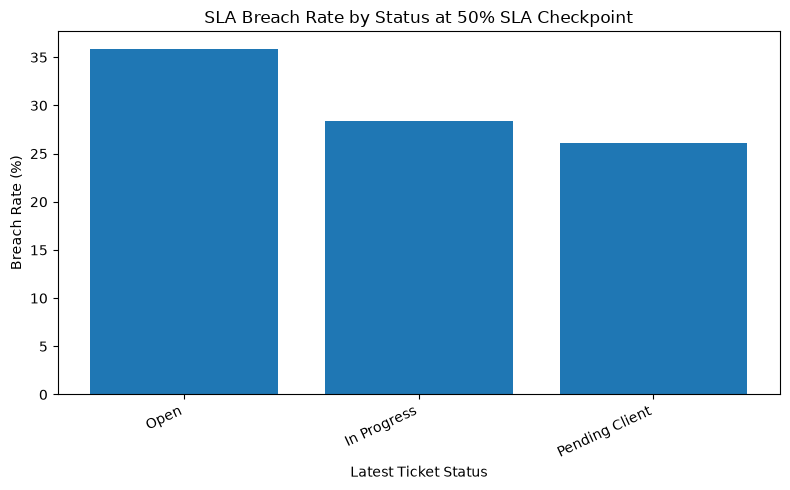

In [125]:
# Calculate SLA breach statistics for each latest status
status_summary = (
    early_warning_model.groupby("LatestStatusAtCheckpoint")
    .agg(
        TotalTickets=("SLABreached", "count"),
        BreachedTickets=("SLABreached", "sum"),
        BreachRate=("SLABreached", "mean")
    )
    .reset_index()
)

# Convert the breach rate to percentage
status_summary["BreachRate"] = (
    status_summary["BreachRate"] * 100
)

# Sort from highest to lowest breach rate
status_summary = status_summary.sort_values(
    "BreachRate",
    ascending=False
)

# Display the summary
display(status_summary)

# Plot SLA breach rate by latest status
plt.figure(figsize=(8, 5))

plt.bar(
    status_summary["LatestStatusAtCheckpoint"],
    status_summary["BreachRate"]
)

# Add chart labels
plt.title("SLA Breach Rate by Status at 50% SLA Checkpoint")
plt.xlabel("Latest Ticket Status")
plt.ylabel("Breach Rate (%)")

# Improve readability
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

# Display the chart
plt.show()

,StatusChangesSoFar,TotalTickets,BreachedTickets,BreachRate
0,0,1718,491,28.579744
1,1,957,263,27.481714


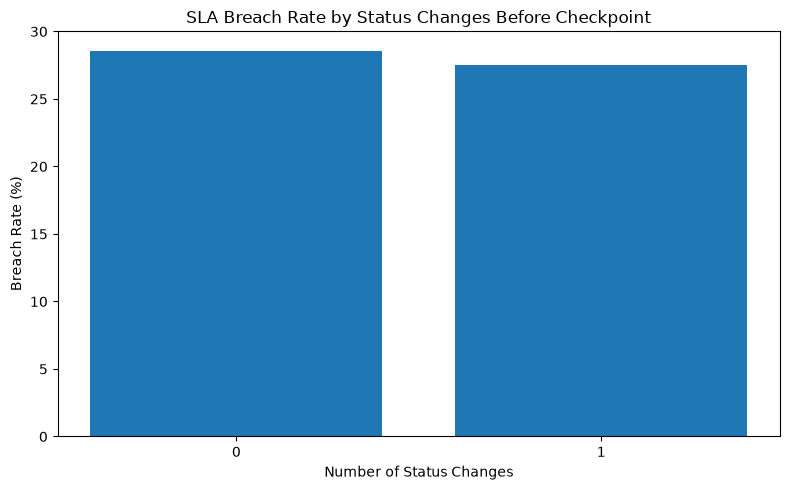

In [126]:
# Calculate SLA breach statistics by number of status changes
status_change_summary = (
    early_warning_model.groupby("StatusChangesSoFar")
    .agg(
        TotalTickets=("SLABreached", "count"),
        BreachedTickets=("SLABreached", "sum"),
        BreachRate=("SLABreached", "mean")
    )
    .reset_index()
)

# Convert the breach rate to percentage
status_change_summary["BreachRate"] = (
    status_change_summary["BreachRate"] * 100
)

# Display the results
display(status_change_summary)

# Plot the relationship
plt.figure(figsize=(8, 5))

plt.bar(
    status_change_summary["StatusChangesSoFar"].astype(str),
    status_change_summary["BreachRate"]
)

# Add chart labels
plt.title("SLA Breach Rate by Status Changes Before Checkpoint")
plt.xlabel("Number of Status Changes")
plt.ylabel("Breach Rate (%)")

# Display the chart
plt.tight_layout()
plt.show()

The initial operational features show limited separation between breached and non-breached tickets.

Average ticket activity was very similar between the two groups:

- The number of actions recorded before the checkpoint was approximately 3.3 for both breached and non-breached tickets.
- The average number of status changes was also very similar.
- Average response delay was approximately 5 hours for both groups.
- The time since the most recent ticket activity was approximately 15 hours for both groups.

The number of status changes also showed little difference in SLA breach rate, suggesting that this variable alone is unlikely to provide strong predictive information.

However, the latest ticket status at the 50% SLA checkpoint showed a clearer relationship with breach risk. Tickets that remained `Open` had the highest breach rate, while tickets already marked `In Progress` or `Pending Client` had lower breach rates.

This suggests that the ticket's operational state at the prediction checkpoint may provide more useful information than simple activity counts alone.

#### First-Response SLA Performance

In [127]:
# Select the first-response SLA rules
# Each rule is determined by ContractTier and PriorityID
response_sla_rules = sla_definitions[
    [
        "ContractTier",
        "PriorityID",
        "FirstResponseHours"
    ]
].copy()

# Add the first-response SLA requirement to each early-warning ticket
early_warning_model = early_warning_model.merge(
    response_sla_rules,
    on=["ContractTier", "PriorityID"],
    how="left"
)

# Rename the SLA requirement for easier interpretation
early_warning_model = early_warning_model.rename(
    columns={
        "FirstResponseHours": "FirstResponseTargetHours"
    }
)

In [128]:
# Calculate how large the response delay was
# relative to the allowed first-response SLA
early_warning_model["ResponseSLARatio"] = (
    early_warning_model["ResponseDelayHours"]
    / early_warning_model["FirstResponseTargetHours"]
)

# Identify tickets that had already missed
# their first-response SLA by the prediction checkpoint
early_warning_model["ResponseSLAMissed"] = (
    early_warning_model["ResponseDelayHours"]
    > early_warning_model["FirstResponseTargetHours"]
).astype(int)

# Preview the new features
early_warning_model[
    [
        "PriorityLabel",
        "ContractTier",
        "ResponseDelayHours",
        "FirstResponseTargetHours",
        "ResponseSLARatio",
        "ResponseSLAMissed",
        "SLABreached"
    ]
].head(10)

,PriorityLabel,ContractTier,ResponseDelayHours,FirstResponseTargetHours,ResponseSLARatio,ResponseSLAMissed,SLABreached
0,P3 Standard,Standard,2.766667,8.0,0.345833,0,0
1,P1 Critical,Standard,1.400000,2.0,0.700000,0,0
2,P2 High,Premium,1.416667,2.0,0.708333,0,1
3,P3 Standard,Premium,3.416667,4.0,0.854167,0,0
4,P3 Standard,Premium,2.366667,4.0,0.591667,0,0
5,P2 High,Standard,10.500000,4.0,2.625000,1,1
6,P3 Standard,Premium,6.833333,4.0,1.708333,1,0
7,P3 Standard,Premium,2.683333,4.0,0.670833,0,1
8,P2 High,Standard,3.066667,4.0,0.766667,0,0
9,P3 Standard,Standard,3.700000,8.0,0.462500,0,0


,ResponseSLAMissed,TotalTickets,BreachedTickets,BreachRate
0,Response SLA Met,2130,593,27.840376
1,Response SLA Missed,545,161,29.541284


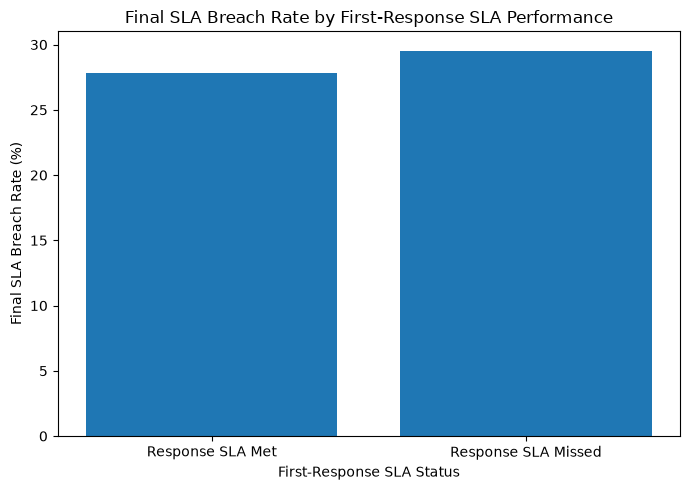

In [129]:
# Compare eventual SLA breach rates based on
# whether the first-response SLA was missed
response_sla_summary = (
    early_warning_model.groupby("ResponseSLAMissed")
    .agg(
        TotalTickets=("SLABreached", "count"),
        BreachedTickets=("SLABreached", "sum"),
        BreachRate=("SLABreached", "mean")
    )
    .reset_index()
)

# Convert breach rate to percentage
response_sla_summary["BreachRate"] = (
    response_sla_summary["BreachRate"] * 100
)

# Replace numeric values with readable labels
response_sla_summary["ResponseSLAMissed"] = (
    response_sla_summary["ResponseSLAMissed"].map({
        0: "Response SLA Met",
        1: "Response SLA Missed"
    })
)

# Display the results
display(response_sla_summary)

# Plot eventual SLA breach rate by first-response SLA performance
plt.figure(figsize=(7, 5))

plt.bar(
    response_sla_summary["ResponseSLAMissed"],
    response_sla_summary["BreachRate"]
)

# Add chart labels
plt.title("Final SLA Breach Rate by First-Response SLA Performance")
plt.xlabel("First-Response SLA Status")
plt.ylabel("Final SLA Breach Rate (%)")

# Display the chart
plt.tight_layout()
plt.show()

Tickets that had already missed their first-response SLA at the 50% prediction checkpoint showed a slightly higher final SLA breach rate than tickets that had met their first-response target.

However, the difference between the two groups is relatively small. This suggests that missing the first-response SLA alone is not a strong predictor of eventual resolution SLA breach.

The continuous `ResponseSLARatio` may still provide useful information because it captures how close each ticket is to, or how far it has exceeded, its allowed first-response time.

First-response performance will therefore be retained as part of the operational feature set and evaluated together with ticket status, activity, and other ticket characteristics.

#### Enhanced Early-Warning Feature Set

In [130]:
# Select static and operational features for the enhanced model
enhanced_features = [
    # Ticket characteristics
    "PriorityLabel",
    "CategoryName",
    "Channel",

    # Client information
    "ContractTier",
    "SLACreditClause",

    # Agent information
    "Hub",
    "DailyCapacity",

    # Ticket creation time
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth",

    # SLA information
    "SLAWindowHours",

    # Operational information available at the checkpoint
    "ActionsSoFar",
    "StatusChangesSoFar",
    "ResponseDelayHours",
    "ResponseSLARatio",
    "ResponseSLAMissed",
    "HoursSinceLastAction",
    "LatestStatusAtCheckpoint"
]

# Create the enhanced feature dataset
X_enhanced = early_warning_model[
    enhanced_features
].copy()

# Create the target variable
y_enhanced = early_warning_model[
    "SLABreached"
].copy()

# Check the dataset dimensions
print("X shape:", X_enhanced.shape)
print("y shape:", y_enhanced.shape)

X shape: (2675, 18)
y shape: (2675,)


## Enhanced Model Train-Test Split

The enhanced early-warning dataset contains only tickets that were still unresolved at the 50% SLA prediction checkpoint.

The dataset is divided into training and testing sets using an 80/20 stratified split. Stratification preserves the proportion of breached and non-breached tickets in both datasets.

Because this modelling population differs from the original full ticket dataset, the enhanced model will primarily be evaluated on its own test set rather than compared directly using accuracy alone with the earlier models.

In [131]:
# Split the enhanced dataset into training and testing sets
# 80% of the tickets will be used for training and 20% for testing
# Stratification keeps the SLA breach proportion similar in both sets
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_enhanced,
    y_enhanced,
    test_size=0.20,
    random_state=42,
    stratify=y_enhanced
)

# Check the dimensions of the training and testing datasets
print("X_train shape:", X_train_enhanced.shape)
print("X_test shape:", X_test_enhanced.shape)
print("y_train shape:", y_train_enhanced.shape)
print("y_test shape:", y_test_enhanced.shape)

X_train shape: (2140, 18)
X_test shape: (535, 18)
y_train shape: (2140,)
y_test shape: (535,)


In [132]:
# Check the SLA breach distribution in the enhanced training set
print("Training target distribution:")
print(
    y_train_enhanced.value_counts(normalize=True) * 100
)

# Check the SLA breach distribution in the enhanced testing set
print("\nTesting target distribution:")
print(
    y_test_enhanced.value_counts(normalize=True) * 100
)

Training target distribution:
SLABreached
0    71.82243
1    28.17757
Name: proportion, dtype: float64

Testing target distribution:
SLABreached
0    71.775701
1    28.224299
Name: proportion, dtype: float64


The enhanced feature set contains categorical, numerical, and binary variables.

Categorical variables are converted into numerical form using One-Hot Encoding. Numerical variables are standardised using Standard Scaling, while binary variables that are already represented as 0 and 1 are kept unchanged.

The preprocessing transformer will be included directly in the modelling pipeline to ensure consistent processing of training and testing data.

In [133]:
# Define categorical features that require One-Hot Encoding
categorical_features_enhanced = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "Hub",
    "CreatedDayOfWeek",
    "LatestStatusAtCheckpoint"
]

# Define numerical features that require standardisation
numerical_features_enhanced = [
    "DailyCapacity",
    "CreatedHour",
    "CreatedMonth",
    "SLAWindowHours",
    "ActionsSoFar",
    "StatusChangesSoFar",
    "ResponseDelayHours",
    "ResponseSLARatio",
    "HoursSinceLastAction"
]

# Define binary features that are already represented as 0 and 1
binary_features_enhanced = [
    "SLACreditClause",
    "ResponseSLAMissed"
]

In [134]:
# Create the preprocessing transformer for the enhanced feature set
preprocessor_enhanced = ColumnTransformer(
    transformers=[
        
        # Convert categorical features into numerical dummy variables
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_enhanced
        ),

        # Standardise numerical features
        (
            "numerical",
            StandardScaler(),
            numerical_features_enhanced
        ),

        # Keep binary features unchanged
        (
            "binary",
            "passthrough",
            binary_features_enhanced
        )
    ]
)

# Display the enhanced preprocessing setup
preprocessor_enhanced

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

Three classification models are trained using the enhanced feature set:

- Class-weighted Logistic Regression
- XGBoost
- LightGBM

All three models use the same training and testing datasets and the same operational features available at the 50% SLA prediction checkpoint.

This allows a fair comparison of whether the newly engineered operational features improve SLA breach prediction.

In [135]:
# Create the enhanced class-weighted Logistic Regression pipeline
enhanced_logistic_model = Pipeline(
    steps=[
        # Apply preprocessing to the enhanced feature set
        ("preprocessor", preprocessor_enhanced),

        # Train Logistic Regression with class balancing
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train the model
enhanced_logistic_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Confirm successful training
print("Enhanced Weighted Logistic Regression trained successfully.")

Enhanced Weighted Logistic Regression trained successfully.


In [136]:
# Generate class predictions
y_pred_log_enhanced = enhanced_logistic_model.predict(
    X_test_enhanced
)

# Generate predicted probabilities for SLA breach
y_prob_log_enhanced = enhanced_logistic_model.predict_proba(
    X_test_enhanced
)[:, 1]

# Calculate evaluation metrics
enhanced_log_accuracy = accuracy_score(
    y_test_enhanced,
    y_pred_log_enhanced
)

enhanced_log_precision = precision_score(
    y_test_enhanced,
    y_pred_log_enhanced
)

enhanced_log_recall = recall_score(
    y_test_enhanced,
    y_pred_log_enhanced
)

enhanced_log_f1 = f1_score(
    y_test_enhanced,
    y_pred_log_enhanced
)

enhanced_log_roc_auc = roc_auc_score(
    y_test_enhanced,
    y_prob_log_enhanced
)

# Display the results
print(f"Accuracy:  {enhanced_log_accuracy:.4f}")
print(f"Precision: {enhanced_log_precision:.4f}")
print(f"Recall:    {enhanced_log_recall:.4f}")
print(f"F1-Score:  {enhanced_log_f1:.4f}")
print(f"ROC-AUC:   {enhanced_log_roc_auc:.4f}")

Accuracy:  0.5140
Precision: 0.2739
Recall:    0.4371
F1-Score:  0.3367
ROC-AUC:   0.5130


In [137]:
# Display the classification report
print(
    classification_report(
        y_test_enhanced,
        y_pred_log_enhanced,
        zero_division=0
    )
)

# Create and display the confusion matrix
enhanced_log_cm = confusion_matrix(
    y_test_enhanced,
    y_pred_log_enhanced
)

print("Confusion Matrix:")
print(enhanced_log_cm)

              precision    recall  f1-score   support

           0       0.71      0.54      0.62       384
           1       0.27      0.44      0.34       151

    accuracy                           0.51       535
   macro avg       0.49      0.49      0.48       535
weighted avg       0.59      0.51      0.54       535

Confusion Matrix:
[[209 175]
 [ 85  66]]


In [138]:
# Count non-breached and breached tickets in the enhanced training set
negative_count_enhanced = (
    y_train_enhanced == 0
).sum()

positive_count_enhanced = (
    y_train_enhanced == 1
).sum()

# Calculate the imbalance weight for XGBoost
scale_pos_weight_enhanced = (
    negative_count_enhanced
    / positive_count_enhanced
)

# Display the calculated weight
print(
    "Scale Pos Weight:",
    round(scale_pos_weight_enhanced, 2)
)

Scale Pos Weight: 2.55


In [139]:
# Create the enhanced XGBoost pipeline
enhanced_xgb_model = Pipeline(
    steps=[
        # Apply preprocessing
        ("preprocessor", preprocessor_enhanced),

        # Train XGBoost
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_enhanced,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

# Train the model
enhanced_xgb_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Confirm training
print("Enhanced XGBoost trained successfully.")

Enhanced XGBoost trained successfully.


In [140]:
# Generate predictions
y_pred_xgb_enhanced = enhanced_xgb_model.predict(
    X_test_enhanced
)

# Generate SLA breach probabilities
y_prob_xgb_enhanced = enhanced_xgb_model.predict_proba(
    X_test_enhanced
)[:, 1]

# Calculate evaluation metrics
enhanced_xgb_accuracy = accuracy_score(
    y_test_enhanced,
    y_pred_xgb_enhanced
)

enhanced_xgb_precision = precision_score(
    y_test_enhanced,
    y_pred_xgb_enhanced
)

enhanced_xgb_recall = recall_score(
    y_test_enhanced,
    y_pred_xgb_enhanced
)

enhanced_xgb_f1 = f1_score(
    y_test_enhanced,
    y_pred_xgb_enhanced
)

enhanced_xgb_roc_auc = roc_auc_score(
    y_test_enhanced,
    y_prob_xgb_enhanced
)

# Display the results
print(f"Accuracy:  {enhanced_xgb_accuracy:.4f}")
print(f"Precision: {enhanced_xgb_precision:.4f}")
print(f"Recall:    {enhanced_xgb_recall:.4f}")
print(f"F1-Score:  {enhanced_xgb_f1:.4f}")
print(f"ROC-AUC:   {enhanced_xgb_roc_auc:.4f}")

Accuracy:  0.5664
Precision: 0.2923
Recall:    0.3775
F1-Score:  0.3295
ROC-AUC:   0.5299


In [141]:
# Display the classification report
print(
    classification_report(
        y_test_enhanced,
        y_pred_xgb_enhanced,
        zero_division=0
    )
)

# Create and display the confusion matrix
enhanced_xgb_cm = confusion_matrix(
    y_test_enhanced,
    y_pred_xgb_enhanced
)

print("Confusion Matrix:")
print(enhanced_xgb_cm)

              precision    recall  f1-score   support

           0       0.72      0.64      0.68       384
           1       0.29      0.38      0.33       151

    accuracy                           0.57       535
   macro avg       0.51      0.51      0.50       535
weighted avg       0.60      0.57      0.58       535

Confusion Matrix:
[[246 138]
 [ 94  57]]


In [142]:
# Create the enhanced LightGBM pipeline
enhanced_lgbm_model = Pipeline(
    steps=[
        # Apply preprocessing
        ("preprocessor", preprocessor_enhanced),

        # Train LightGBM with class balancing
        ("classifier", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            num_leaves=15,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        ))
    ]
)

# Train the model
enhanced_lgbm_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

# Confirm successful training
print("Enhanced LightGBM trained successfully.")

Enhanced LightGBM trained successfully.


In [143]:
# Generate predictions
y_pred_lgbm_enhanced = enhanced_lgbm_model.predict(
    X_test_enhanced
)

# Generate predicted SLA breach probabilities
y_prob_lgbm_enhanced = enhanced_lgbm_model.predict_proba(
    X_test_enhanced
)[:, 1]

# Calculate evaluation metrics
enhanced_lgbm_accuracy = accuracy_score(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

enhanced_lgbm_precision = precision_score(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

enhanced_lgbm_recall = recall_score(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

enhanced_lgbm_f1 = f1_score(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

enhanced_lgbm_roc_auc = roc_auc_score(
    y_test_enhanced,
    y_prob_lgbm_enhanced
)

# Display the results
print(f"Accuracy:  {enhanced_lgbm_accuracy:.4f}")
print(f"Precision: {enhanced_lgbm_precision:.4f}")
print(f"Recall:    {enhanced_lgbm_recall:.4f}")
print(f"F1-Score:  {enhanced_lgbm_f1:.4f}")
print(f"ROC-AUC:   {enhanced_lgbm_roc_auc:.4f}")

Accuracy:  0.5944
Precision: 0.3382
Recall:    0.4570
F1-Score:  0.3887
ROC-AUC:   0.5352


In [144]:
# Display the classification report
print(
    classification_report(
        y_test_enhanced,
        y_pred_lgbm_enhanced,
        zero_division=0
    )
)

# Create and display the confusion matrix
enhanced_lgbm_cm = confusion_matrix(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

print("Confusion Matrix:")
print(enhanced_lgbm_cm)

              precision    recall  f1-score   support

           0       0.75      0.65      0.70       384
           1       0.34      0.46      0.39       151

    accuracy                           0.59       535
   macro avg       0.55      0.55      0.54       535
weighted avg       0.64      0.59      0.61       535

Confusion Matrix:
[[249 135]
 [ 82  69]]


In [145]:
# Display the classification report
print(
    classification_report(
        y_test_enhanced,
        y_pred_lgbm_enhanced,
        zero_division=0
    )
)

# Create and display the confusion matrix
enhanced_lgbm_cm = confusion_matrix(
    y_test_enhanced,
    y_pred_lgbm_enhanced
)

print("Confusion Matrix:")
print(enhanced_lgbm_cm)

              precision    recall  f1-score   support

           0       0.75      0.65      0.70       384
           1       0.34      0.46      0.39       151

    accuracy                           0.59       535
   macro avg       0.55      0.55      0.54       535
weighted avg       0.64      0.59      0.61       535

Confusion Matrix:
[[249 135]
 [ 82  69]]


The enhanced models were trained using ticket characteristics together with operational information available at the 50% SLA prediction checkpoint.

Among the three models, LightGBM achieved the strongest overall performance:

- Accuracy: **59.40%**
- Precision: **33.82%**
- Recall: **45.70%**
- F1-score: **38.87%**
- ROC-AUC: **53.52%**

The LightGBM confusion matrix shows:

- **249 true negatives**
- **135 false positives**
- **82 false negatives**
- **69 true positives**

Compared with the enhanced Logistic Regression and XGBoost models, LightGBM produced the best precision, recall, F1-score, and ROC-AUC combination.

The operational features therefore appear to provide some useful information for identifying tickets at risk of SLA breach. However, the ROC-AUC remains relatively low, indicating that the model still has limited ability to clearly separate high-risk and low-risk tickets.

The enhanced LightGBM model is therefore the strongest candidate tested so far, but its performance is not yet strong enough to be considered a reliable production model.

#### Static vs Operational Feature Comparison

In [146]:
# Select only the static features available before operational activity is considered
static_features_early_warning = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "SLACreditClause",
    "Hub",
    "DailyCapacity",
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth",
    "SLAWindowHours"
]

# Use the SAME training and testing rows as the enhanced model
# This makes the comparison fair
X_train_static_ew = X_train_enhanced[
    static_features_early_warning
].copy()

X_test_static_ew = X_test_enhanced[
    static_features_early_warning
].copy()

# Confirm the dimensions
print("Static training shape:", X_train_static_ew.shape)
print("Static testing shape:", X_test_static_ew.shape)

Static training shape: (2140, 11)
Static testing shape: (535, 11)


In [147]:
# Define categorical static features
categorical_static_ew = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "Hub",
    "CreatedDayOfWeek"
]

# Define numerical static features
numerical_static_ew = [
    "DailyCapacity",
    "CreatedHour",
    "CreatedMonth",
    "SLAWindowHours"
]

# Define binary static features
binary_static_ew = [
    "SLACreditClause"
]

# Create the static-only preprocessing transformer
preprocessor_static_ew = ColumnTransformer(
    transformers=[
        # Encode categorical variables
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_static_ew
        ),

        # Standardise numerical variables
        (
            "numerical",
            StandardScaler(),
            numerical_static_ew
        ),

        # Keep binary variables unchanged
        (
            "binary",
            "passthrough",
            binary_static_ew
        )
    ]
)

In [148]:
# Create a static-only LightGBM model
# The model uses the same settings as the enhanced LightGBM
static_lgbm_ew = Pipeline(
    steps=[
        ("preprocessor", preprocessor_static_ew),

        ("classifier", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            num_leaves=15,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        ))
    ]
)

# Train using the same early-warning training tickets
static_lgbm_ew.fit(
    X_train_static_ew,
    y_train_enhanced
)

print("Static early-warning LightGBM trained successfully.")

Static early-warning LightGBM trained successfully.


In [149]:
# Generate predictions
y_pred_static_lgbm = static_lgbm_ew.predict(
    X_test_static_ew
)

# Generate breach probabilities
y_prob_static_lgbm = static_lgbm_ew.predict_proba(
    X_test_static_ew
)[:, 1]

# Calculate evaluation metrics
static_lgbm_accuracy = accuracy_score(
    y_test_enhanced,
    y_pred_static_lgbm
)

static_lgbm_precision = precision_score(
    y_test_enhanced,
    y_pred_static_lgbm
)

static_lgbm_recall = recall_score(
    y_test_enhanced,
    y_pred_static_lgbm
)

static_lgbm_f1 = f1_score(
    y_test_enhanced,
    y_pred_static_lgbm
)

static_lgbm_roc_auc = roc_auc_score(
    y_test_enhanced,
    y_prob_static_lgbm
)

# Display the results
print(f"Accuracy:  {static_lgbm_accuracy:.4f}")
print(f"Precision: {static_lgbm_precision:.4f}")
print(f"Recall:    {static_lgbm_recall:.4f}")
print(f"F1-Score:  {static_lgbm_f1:.4f}")
print(f"ROC-AUC:   {static_lgbm_roc_auc:.4f}")

Accuracy:  0.5346
Precision: 0.2525
Recall:    0.3311
F1-Score:  0.2865
ROC-AUC:   0.5029


The static-only and enhanced LightGBM models were evaluated using the same early-warning ticket population and the same train-test split.

The static-only LightGBM achieved:

- Accuracy: **53.46%**
- Precision: **25.25%**
- Recall: **33.11%**
- F1-score: **28.65%**
- ROC-AUC: **50.29%**

After adding operational features available at the 50% SLA checkpoint, the enhanced LightGBM achieved:

- Accuracy: **59.40%**
- Precision: **33.82%**
- Recall: **45.70%**
- F1-score: **38.87%**
- ROC-AUC: **53.52%**

The enhanced model performed better across all evaluation metrics, showing that ticket-progress information provides additional predictive value beyond static ticket, client, agent, and SLA characteristics.

In particular, recall improved, meaning that the enhanced model was able to identify a larger proportion of tickets that eventually breached SLA.

However, the overall ROC-AUC remains relatively low. Therefore, while operational features improve early-warning performance, the current model still has limited ability to clearly separate high-risk and low-risk tickets and should not yet be considered production-ready.

In [150]:
# Compare static and enhanced LightGBM performance
# Both models were evaluated on the same early-warning test population

early_warning_comparison = pd.DataFrame({
    "Model": [
        "Static LightGBM",
        "Enhanced LightGBM"
    ],

    "Accuracy": [
        static_lgbm_accuracy,
        enhanced_lgbm_accuracy
    ],

    "Precision": [
        static_lgbm_precision,
        enhanced_lgbm_precision
    ],

    "Recall": [
        static_lgbm_recall,
        enhanced_lgbm_recall
    ],

    "F1-Score": [
        static_lgbm_f1,
        enhanced_lgbm_f1
    ],

    "ROC-AUC": [
        static_lgbm_roc_auc,
        enhanced_lgbm_roc_auc
    ]
})

# Round the values for easier interpretation
early_warning_comparison = early_warning_comparison.round(4)

# Display the comparison table
early_warning_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Static LightGBM,0.5346,0.2525,0.3311,0.2865,0.5029
1,Enhanced LightGBM,0.5944,0.3382,0.4570,0.3887,0.5352


#### Model Explainability: Feature Importance

In [151]:
# Access the fitted preprocessing transformer
fitted_preprocessor = enhanced_lgbm_model.named_steps["preprocessor"]

# Access the fitted LightGBM classifier
fitted_lgbm = enhanced_lgbm_model.named_steps["classifier"]

# Get the feature names after One-Hot Encoding and preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get gain-based feature importance from the trained LightGBM model
gain_importance = fitted_lgbm.booster_.feature_importance(
    importance_type="gain"
)

# Create a DataFrame containing each feature and its importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gain_importance
})

# Remove preprocessing prefixes to make feature names easier to read
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

# Convert raw importance values into percentages
feature_importance["ImportancePercent"] = (
    feature_importance["Importance"]
    / feature_importance["Importance"].sum()
) * 100

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Display the 15 most important features
feature_importance.head(15)

,Feature,Importance,ImportancePercent
36,ResponseDelayHours,1430.116455,14.815022
38,HoursSinceLastAction,1414.934213,14.657744
37,ResponseSLARatio,1290.632763,13.370067
32,CreatedMonth,1096.662092,11.360664
31,CreatedHour,1032.411158,10.695069
30,DailyCapacity,671.091586,6.952047
17,Hub_Edinburgh,276.124281,2.860457
34,ActionsSoFar,169.471850,1.755612
33,SLAWindowHours,169.089812,1.751654
5,CategoryName_Billing Issue,156.253679,1.618681


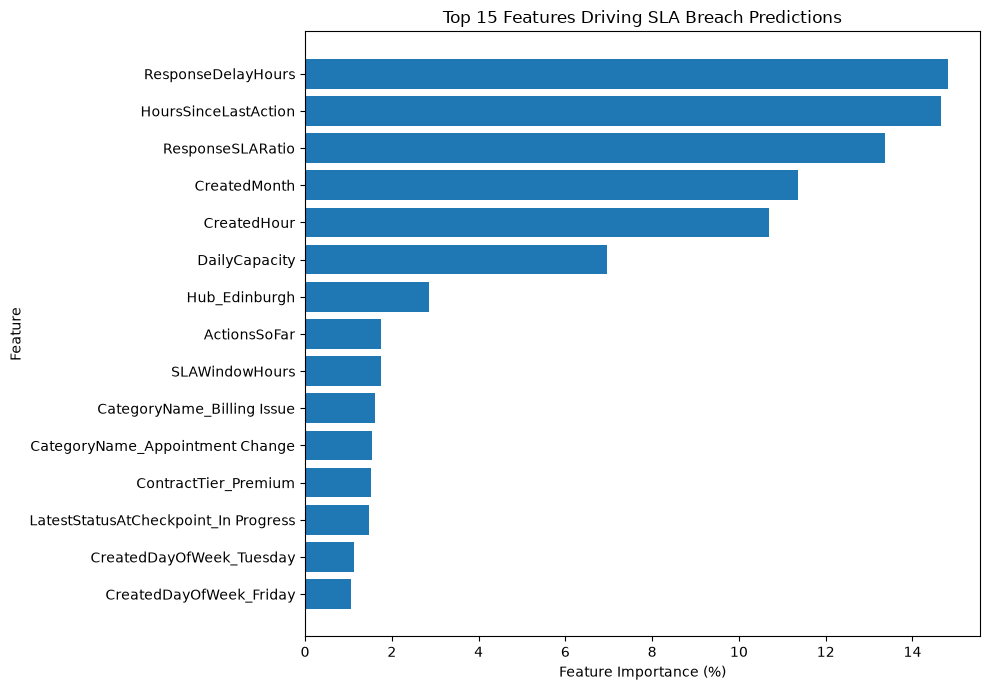

In [152]:
# Select the 15 most important model features
top_features = feature_importance.head(15).sort_values(
    "ImportancePercent",
    ascending=True
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["ImportancePercent"]
)

# Add chart title and axis labels
plt.title("Top 15 Features Driving SLA Breach Predictions")
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

The enhanced LightGBM model relies most heavily on operational and timing-related features when estimating SLA breach risk.

The three most important features are:

- `ResponseDelayHours` – approximately **14.82%**
- `HoursSinceLastAction` – approximately **14.66%**
- `ResponseSLARatio` – approximately **13.37%**

Together, these features show that ticket response speed and recent ticket activity provide more predictive information than most static ticket characteristics.

Time-related features such as `CreatedMonth` and `CreatedHour` also contribute substantially to the model, while `DailyCapacity` provides additional operational information.

Static features such as ticket category, contract tier, hub, and day of week contribute less individually.

These findings support the earlier model comparison, where adding operational features improved early-warning performance.

However, feature importance only measures how strongly the model uses a feature. It does not show whether higher or lower values increase SLA breach risk.

#### SHAP Model Explainability

In [153]:
# Import SHAP for model explainability
import shap

c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [154]:
# Access the fitted preprocessing transformer
shap_preprocessor = enhanced_lgbm_model.named_steps["preprocessor"]

# Access the fitted LightGBM classifier
shap_model = enhanced_lgbm_model.named_steps["classifier"]

# Transform the test data using the same preprocessing
# that was used during model training
X_test_transformed = shap_preprocessor.transform(
    X_test_enhanced
)

# Get the feature names after preprocessing
shap_feature_names = shap_preprocessor.get_feature_names_out()

# Clean the feature names for easier interpretation
shap_feature_names = [
    name
    .replace("categorical__", "")
    .replace("numerical__", "")
    .replace("binary__", "")
    for name in shap_feature_names
]

In [155]:
# Create a SHAP explainer for the trained LightGBM model
explainer = shap.TreeExplainer(shap_model)

# Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(
    X_test_transformed
)

c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


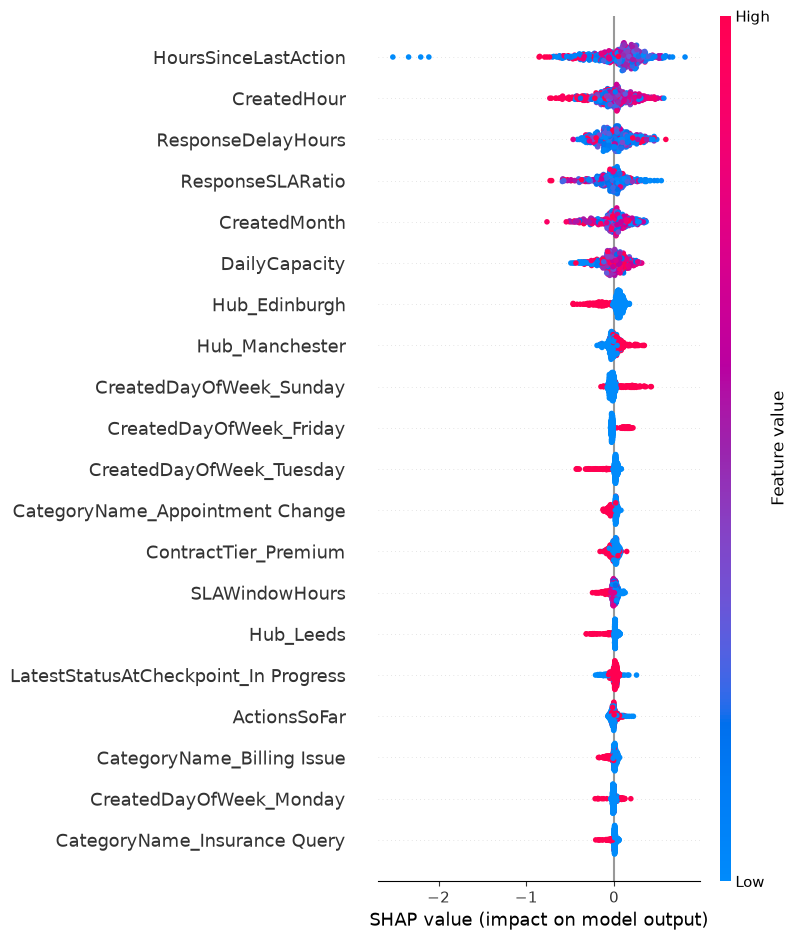

In [156]:
# Create a SHAP summary plot
# This shows both feature importance and the direction
# of each feature's effect on SLA breach predictions
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=shap_feature_names
)

The SHAP analysis confirms that operational and time-related variables play an important role in the enhanced LightGBM model.

The strongest contributors include:

- `HoursSinceLastAction`
- `CreatedHour`
- `ResponseDelayHours`
- `ResponseSLARatio`
- `CreatedMonth`
- `DailyCapacity`

This supports the earlier finding that information about ticket progress and timing provides more predictive value than many static ticket characteristics.

Some features show mixed effects, indicating that their relationship with SLA breach risk is not purely linear. For example, response delay and inactivity can influence risk differently depending on the other characteristics of the ticket.

Several categorical patterns are also visible:

- Tickets associated with `Manchester` tend to push predictions toward higher SLA breach risk.
- `Edinburgh` and `Leeds` tend to push predictions toward lower breach risk.
- Tickets created on `Sunday` and `Friday` tend to contribute more toward breach predictions.
- Tickets created on `Tuesday` tend to contribute more toward non-breach predictions.
- Longer SLA time windows generally appear to reduce predicted breach risk.

Overall, the SHAP analysis shows that the model relies on a combination of operational progress, timing, capacity, and location-related information when estimating SLA breach risk.

These relationships describe how the model makes predictions and should not automatically be interpreted as causal relationships.

## Final Modelling Conclusion

Multiple classification approaches were evaluated for predicting ticket-level SLA breaches, including Logistic Regression, XGBoost, and LightGBM.

The initial models were trained using static ticket, client, agent, SLA, and time-based features. These models showed weak predictive performance, with ROC-AUC values close to random classification.

Further investigation showed that the `SLABreached` target was correctly recorded and matched the actual SLA deadline and resolution timestamps in 100% of resolved tickets.

Operational information from the TicketAuditLog was then incorporated using a 50% SLA prediction checkpoint. Tickets that had already been resolved before this checkpoint were excluded, leaving 2,675 active tickets for the early-warning modelling problem.

The enhanced models included operational features such as response delay, response SLA performance, recent ticket activity, status changes, and ticket status at the checkpoint.

Among the enhanced models, LightGBM achieved the strongest overall performance:

- Accuracy: **59.40%**
- Precision: **33.82%**
- Recall: **45.70%**
- F1-score: **38.87%**
- ROC-AUC: **53.52%**

When evaluated against a static-only LightGBM model using the same early-warning population and test split, the enhanced model performed better across all metrics. This confirms that operational ticket-progress information provides additional predictive value.

Feature importance and SHAP analysis also showed that operational variables such as response delay, recent activity, and response SLA performance were among the strongest contributors to model predictions.

However, overall discrimination remains limited. The enhanced model should therefore be treated as a prototype early-warning model rather than a production-ready SLA prediction system.

## Business Recommendations

The modelling results suggest that SLA breach risk cannot be reliably predicted using static ticket characteristics alone.

NorthBridge should prioritise capturing and monitoring operational ticket-progress information in real time.

Recommended improvements include:

- Track current queue size and agent workload at the time each ticket is being processed.
- Record ticket reassignment and ownership changes throughout the ticket lifecycle.
- Monitor time spent in each operational status.
- Capture waiting time between ticket actions.
- Track workload relative to agent capacity rather than agent capacity alone.
- Develop intermediate risk scores at multiple SLA checkpoints instead of relying on a single prediction at ticket creation.
- Use late-stage escalation information as a secondary warning mechanism because escalations typically occur near the end of the SLA window.
- Continue monitoring model precision and recall before using predicted risk scores to trigger automated interventions.

The current model can support further experimentation and dashboard integration, but human review should remain part of any operational decision based on the risk score.

In [157]:
# Import joblib for saving the trained machine learning pipeline
import joblib

In [158]:
# Save the final enhanced LightGBM pipeline
# The saved file will be created inside the project's model folder
joblib.dump(
    enhanced_lgbm_model,
    "../model/sla_breach_lightgbm_pipeline.pkl"
)

# Confirm that the model was saved
print("Enhanced LightGBM pipeline saved successfully.")

Enhanced LightGBM pipeline saved successfully.
